In [1]:
# %% [markdown]
# # Value-Targeted, Resource-Constrained RL Eavesdropper — Phase 1
# Simulator core: hidden-state generative model, BB84 intercept-resend physics,
# delayed key-pool ledger (dual-ledger design), detection statistic, POMDP env,
# and non-learned baselines (Random, Greedy).

%pip install -q \
    "stable-baselines3>=2.6,<3" \
    "gymnasium>=1.0,<2" \
    "tensorboard>=2.20,<3" \
    "tqdm>=4.66"

# %% Cell 1 — Imports & global config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from collections import deque
from enum import IntEnum

RNG_GLOBAL_SEED = 12345


class Regime(IntEnum):
    CALM = 0
    ACTIVE = 1


class ValueClass(IntEnum):
    LOW = 0
    NORMAL = 1
    HIGH = 2


VALUE_WEIGHTS = {ValueClass.LOW: 0.2, ValueClass.NORMAL: 1.0, ValueClass.HIGH: 5.0}

# Regime transition matrix (slow, sticky macro state — NOT observed by Eve directly)
REGIME_TRANS = np.array([
    [0.98, 0.02],   # from CALM
    [0.05, 0.95],   # from ACTIVE
])

# Value-class transition matrices, CONDITIONED on regime.
# Under ACTIVE regime, HIGH-value periods are far more likely and persistent.
VALUE_TRANS = {
    Regime.CALM: np.array([
        [0.85, 0.14, 0.01],   # from LOW
        [0.10, 0.85, 0.05],   # from NORMAL
        [0.05, 0.35, 0.60],   # from HIGH
    ]),
    Regime.ACTIVE: np.array([
        [0.60, 0.35, 0.05],
        [0.05, 0.70, 0.25],
        [0.02, 0.18, 0.80],
    ]),
}

# Traffic generation parameters per value class (this is what Nexus-trace calibration
# should eventually replace/validate — for now these are synthetic placeholders).
CLASS_PARAMS = {
    ValueClass.LOW:    dict(rate=3.0,  burst_sigma=0.15, size_mean=250, size_std=60),
    ValueClass.NORMAL: dict(rate=10.0, burst_sigma=0.30, size_mean=450, size_std=120),
    ValueClass.HIGH:   dict(rate=25.0, burst_sigma=0.55, size_mean=900, size_std=250),
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.7 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
# %% Cell 2 — Hidden-state process (Regime + ValueClass)
class HiddenStateProcess:
    """
    Two-timescale hidden state:
      - Regime: slow, sticky macro state (calm/active), NEVER observed by Eve.
      - ValueClass: faster value-context variable whose transition dynamics
        depend on Regime. This is C_t in the writeup — hidden from Eve,
        used only by the simulator for reward/eval.

    Rationale for the two-level design (see accompanying notes): if C_t were a
    simple single Markov chain, its autocorrelation decays geometrically with
    lag, so at large buffering delay Delta, current traffic tells you almost
    nothing about C_{t+Delta} and *no* policy (greedy or RL) could exploit it —
    the hypothesis "RL advantage grows with Delta" would have no mechanism to
    show up. The slow Regime variable provides a longer-memory, weakly
    observable signal (via persistent patterns in traffic statistics over a
    window) that a temporally-integrating policy can in principle extract even
    when C_t itself is uninformative at lag Delta. This is what "sequential
    decision-making" is actually supposed to buy Eve.
    """

    def __init__(self, rng: np.random.Generator):
        self.rng = rng
        self.regime = Regime.CALM
        self.value = ValueClass.NORMAL

    def step(self):
        # regime transition
        p_reg = REGIME_TRANS[self.regime]
        self.regime = Regime(self.rng.choice(2, p=p_reg))
        # value transition conditioned on (new) regime
        p_val = VALUE_TRANS[self.regime][self.value]
        self.value = ValueClass(self.rng.choice(3, p=p_val))
        return self.regime, self.value


In [3]:
# %% Cell 3 — Traffic generator (raw process + noisy windowed observation)
class TrafficGenerator:
    """
    Given the current hidden ValueClass, generates raw per-round traffic
    (message count, total bytes), and maintains a rolling window to compute
    the *observable* metadata features Eve actually sees (with observation
    noise). This is the O_t <- C_t generative link.
    """

    def __init__(self, rng: np.random.Generator, window=5, metadata_noise_std=0.10):
        self.rng = rng
        self.window = window
        self.noise_std = metadata_noise_std
        self.count_hist = deque(maxlen=window)
        self.bytes_hist = deque(maxlen=window)

    def reset(self):
        self.count_hist.clear()
        self.bytes_hist.clear()
        # warm up window with zeros so early-episode features aren't NaN
        for _ in range(self.window):
            self.count_hist.append(0)
            self.bytes_hist.append(0.0)

    def step(self, value_class: ValueClass, shaper=None):
        p = CLASS_PARAMS[value_class]
        burst_mult = np.exp(self.rng.normal(0, p["burst_sigma"]))
        n_messages = self.rng.poisson(p["rate"] * burst_mult)

        if n_messages > 0:
            m, s = p["size_mean"], p["size_std"]
            sigma2 = np.log(1 + (s ** 2) / (m ** 2))
            mu = np.log(m) - sigma2 / 2
            sizes = self.rng.lognormal(mu, np.sqrt(sigma2), size=n_messages)
            total_bytes = float(sizes.sum())
        else:
            total_bytes = 0.0

        true_n_messages, true_total_bytes = n_messages, total_bytes
        obs_n_messages, obs_total_bytes = (
            shaper.shape(n_messages, total_bytes) if shaper is not None else (n_messages, total_bytes)
        )
        self.count_hist.append(obs_n_messages)
        self.bytes_hist.append(obs_total_bytes)

        counts = np.array(self.count_hist, dtype=float)
        byts = np.array(self.bytes_hist, dtype=float)

        traffic_rate_true = counts.mean()
        burstiness_true = counts.std() / (counts.mean() + 1e-6)   # coeff. of variation proxy
        mean_size_true = (byts.sum() / max(counts.sum(), 1e-6))

        def noisy(x):
            return max(0.0, x * (1 + self.rng.normal(0, self.noise_std)))

        obs = dict(
            traffic_rate_obs=noisy(traffic_rate_true),
            burstiness_obs=noisy(burstiness_true),
            size_obs=noisy(mean_size_true),
        )
        raw = dict(n_messages=true_n_messages, total_bytes=true_total_bytes)
        return raw, obs


In [4]:
# %% Cell 3b — Nexus trace ingestion
def load_nexus_trace(csv_path, round_seconds=1.0):
    """Expects CSV with columns: timestamp, conversation_id, size_bytes
    (export via Kafka consumer log of PUSH_MESSAGE/SEND_ACK events, or
    messaging-service metrics during a load-test run)."""
    df = pd.read_csv(csv_path)
    df["round_idx"] = (df["timestamp"] // round_seconds).astype(int)
    grouped = df.groupby("round_idx").agg(
        n_messages=("size_bytes", "count"), total_bytes=("size_bytes", "sum")
    ).reset_index()
    full_idx = pd.RangeIndex(grouped["round_idx"].min(), grouped["round_idx"].max() + 1)
    grouped = grouped.set_index("round_idx").reindex(full_idx, fill_value=0).reset_index()
    grouped.columns = ["round_idx", "n_messages", "total_bytes"]
    return grouped

# nexus_trace_df = load_nexus_trace("nexus_loadtest_trace.csv", round_seconds=1.0)

In [5]:
# %% Cell 3c — Calibrate CLASS_PARAMS against the empirical Nexus trace
def calibrate_class_params_from_trace(trace_df, window=5):
    rate = trace_df["n_messages"].rolling(window, min_periods=1).mean()
    q_low, q_high = rate.quantile([0.33, 0.66])
    buckets = {
        ValueClass.LOW: trace_df[rate <= q_low],
        ValueClass.NORMAL: trace_df[(rate > q_low) & (rate <= q_high)],
        ValueClass.HIGH: trace_df[rate > q_high],
    }
    calibrated = {}
    for vc, sub in buckets.items():
        if len(sub) < 5:
            calibrated[vc] = CLASS_PARAMS[vc]; continue
        msgs = sub["n_messages"].values
        sizes = (sub["total_bytes"] / sub["n_messages"].clip(lower=1)).values
        calibrated[vc] = dict(
            rate=float(msgs.mean()),
            burst_sigma=float(np.std(np.log(msgs.clip(min=1) / max(msgs.mean(), 1e-6) + 1e-6))),
            size_mean=float(sizes.mean()), size_std=float(sizes.std() + 1e-6),
        )
    return calibrated

def validate_calibration(trace_df, calibrated_params, n_rounds=None, seed=0):
    from statsmodels.graphics.tsaplots import acf
    n_rounds = n_rounds or len(trace_df)
    rng = np.random.default_rng(seed)
    gen = TrafficGenerator(rng, window=5, metadata_noise_std=0.0); gen.reset()
    global CLASS_PARAMS
    old_params = CLASS_PARAMS.copy(); CLASS_PARAMS.update(calibrated_params)
    synth_counts, hidden = [], HiddenStateProcess(rng)
    for _ in range(n_rounds):
        _, vc = hidden.step()
        raw, _ = gen.step(vc)
        synth_counts.append(raw["n_messages"])
    CLASS_PARAMS.update(old_params)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].hist(trace_df["n_messages"], bins=30, alpha=0.5, density=True, label="Nexus real")
    ax[0].hist(synth_counts, bins=30, alpha=0.5, density=True, label="synthetic (calibrated)")
    ax[0].legend(); ax[0].set_title("messages/round distribution")
    ax[1].plot(acf(trace_df["n_messages"], nlags=20, fft=True), label="Nexus real")
    ax[1].plot(acf(np.array(synth_counts), nlags=20, fft=True), label="synthetic")
    ax[1].legend(); ax[1].set_title("autocorrelation")
    plt.tight_layout(); plt.savefig("nexus_calibration_validation.png", dpi=120); plt.show()

# calibrated = calibrate_class_params_from_trace(nexus_trace_df)
# validate_calibration(nexus_trace_df, calibrated)
# CLASS_PARAMS.update(calibrated)   # only after validating the overlay plots

In [6]:
# %% Cell 3d — Traffic shaping defenses
class TrafficShaper:
    """Applied only to what Eve observes; true consumption/demand is untouched."""
    def __init__(self, mode="none", rng=None, cover_traffic_rate=5.0, jitter_window=3):
        self.mode = mode
        self.rng = rng or np.random.default_rng(0)
        self.cover_traffic_rate = cover_traffic_rate
        self._jitter_buffer = deque(maxlen=jitter_window)

    def shape(self, n_messages, total_bytes):
        if self.mode == "none":
            return n_messages, total_bytes
        if self.mode == "padding":
            const_size = 500.0
            return n_messages, n_messages * const_size
        if self.mode == "cover_traffic":
            cover = self.rng.poisson(self.cover_traffic_rate)
            return n_messages + cover, total_bytes + cover * 500.0
        if self.mode == "jitter":
            self._jitter_buffer.append((n_messages, total_bytes))
            return (np.mean([x[0] for x in self._jitter_buffer]),
                    np.mean([x[1] for x in self._jitter_buffer]))
        raise ValueError(f"unknown shaping mode {self.mode}")

In [7]:
# %% Cell 4 — BB84 intercept-resend physics
def h2(p):
    """Binary entropy, safe at p=0/1."""
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def secure_key_rate(qber):
    """
    Simplified asymptotic BB84 secure-key-rate approximation r(QBER) = 1 - 2*H2(QBER),
    clipped at 0 (hits 0 near ~11% QBER, matching the standard BB84 abort threshold).
    NOTE: this is a simplification for simulation purposes, not a finite-key
    composable-security proof. We use it only to make "how much *legitimate*
    usable key is generated this round" respond realistically to QBER.
    """
    r = 1 - 2 * h2(qber)
    return max(0.0, r)


# Standard individual intercept-resend attack result:
# Eve measures each intercepted qubit in a random basis and resends.
#   - matches Alice's basis w.p. 1/2 -> she learns the bit exactly, no error induced
#   - mismatches w.p. 1/2 -> she guesses w.p. 1/2 correct, and Bob sees an error w.p. 1/2
# => per intercepted+sifted bit: P(bit flip) = 0.25 ; P(Eve correct) = 0.75
QBER_SLOPE = 0.25
EVE_GUESS_ACCURACY = 0.75
EVE_INFO_PER_BIT = 1 + EVE_GUESS_ACCURACY * np.log2(EVE_GUESS_ACCURACY) + \
    (1 - EVE_GUESS_ACCURACY) * np.log2(1 - EVE_GUESS_ACCURACY)  # Shannon info, ~0.1887 bits

print(f"[sanity] Eve Shannon information per intercepted sifted bit: {EVE_INFO_PER_BIT:.4f} bits "
      f"(expected ~0.1887)")


[sanity] Eve Shannon information per intercepted sifted bit: 0.1887 bits (expected ~0.1887)


In [8]:
# %% Cell 5 — Dual-ledger key pool with explicit release delay (Delta)
#
# IMPORTANT DESIGN NOTE (this is the crux of the whole simulator — read carefully):
#
# We track TWO separate ledgers:
#   (a) `available_bits` — the legitimate, properly-secured key pool used for
#       encryption / key-exhaustion / latency (application-level reality).
#   (b) an "exposure" tag attached to each generated batch, representing the
#       AVERAGE fraction of pre-privacy-amplification information Eve holds
#       about that batch (proportional to the intercepted fraction f_t and her
#       per-bit information rate). This tag is tracked ALONGSIDE the secure
#       pool purely as an evaluation/scoring ledger — it does NOT reduce the
#       legitimate key pool's availability, and it is explicitly NOT
#       interpreted as residual information about the final privacy-amplified
#       key (which, if PA is done correctly, should be ~0 regardless of raw
#       interception). It is an "operational exposure" proxy: how much of the
#       raw material behind whatever gets consumed was, on average, partially
#       compromised pre-PA, weighted by how valuable that consumption turned
#       out to be.
#
# Each batch is release-delayed by Delta rounds after generation before it
# enters the "available for consumption" queue. Consumption draws FIFO. This
# delay is the operational analogue of QKD post-processing latency (sifting
# batch collection + error correction + privacy amplification take real time
# before key becomes usable) — so Delta has a genuine physical justification,
# not just being an artificial knob.
class KeyBatch:
    __slots__ = ("bits_remaining", "exposure_rate", "gen_round", "release_round")

    def __init__(self, bits, exposure_rate, gen_round, release_round):
        self.bits_remaining = bits
        self.exposure_rate = exposure_rate
        self.gen_round = gen_round
        self.release_round = release_round


class KeyPoolLedger:
    def __init__(self, delay_rounds: int):
        self.delay = delay_rounds
        self.pipeline = deque()   # batches not yet released
        self.available = deque()  # batches ready for consumption (FIFO)
        self.total_generated = 0.0
        self.total_consumed = 0.0
        self.total_exposure_weighted_consumed = 0.0
        self.total_exhaustion_deficit = 0.0

    def add_batch(self, bits, exposure_rate, current_round):
        if bits <= 0:
            return
        b = KeyBatch(bits, exposure_rate, current_round, current_round + self.delay)
        self.pipeline.append(b)
        self.total_generated += bits

    def _advance_pipeline(self, current_round):
        while self.pipeline and self.pipeline[0].release_round <= current_round:
            self.available.append(self.pipeline.popleft())

    def consume(self, demand_bits, current_round):
        """Returns (bits_consumed, exposure_weighted_bits_consumed, deficit)."""
        self._advance_pipeline(current_round)
        bits_consumed = 0.0
        exposure_weighted = 0.0
        remaining_demand = demand_bits

        while remaining_demand > 1e-9 and self.available:
            batch = self.available[0]
            take = min(batch.bits_remaining, remaining_demand)
            bits_consumed += take
            exposure_weighted += take * batch.exposure_rate
            batch.bits_remaining -= take
            remaining_demand -= take
            if batch.bits_remaining <= 1e-9:
                self.available.popleft()

        deficit = max(0.0, remaining_demand)
        self.total_consumed += bits_consumed
        self.total_exposure_weighted_consumed += exposure_weighted
        self.total_exhaustion_deficit += deficit
        return bits_consumed, exposure_weighted, deficit

    def pool_level(self):
        return sum(b.bits_remaining for b in self.pipeline) + sum(b.bits_remaining for b in self.available)


In [9]:
# %% Cell 6 (REPLACED) — Detection monitor (windowed CUSUM on public QBER samples)
class CusumDetector:
    """
    One-sided CUSUM on the publicly-announced QBER-estimation samples.
    S_t = max(0, S_{t-1} + (qber_hat_t - baseline - slack))
    Flags "detected" when S_t crosses a threshold h.
    """

    def __init__(self, baseline, slack, threshold):
        self.baseline = baseline
        self.slack = slack
        self.threshold = threshold
        self.s = 0.0
        self.max_s = 0.0
        self.triggered_round = None

    def update(self, qber_hat, round_idx):
        self.s = max(0.0, self.s + (qber_hat - self.baseline - self.slack))
        self.max_s = max(self.max_s, self.s)
        if self.s >= self.threshold and self.triggered_round is None:
            self.triggered_round = round_idx
        return self.s


def calibrate_cusum_threshold(qber_baseline, sample_size, n_rounds, slack,
                               target_false_alarm=0.05, n_calib_episodes=3000, seed=999,
                               return_diagnostics=False):
    """
    Simulate the null (no-attack) QBER-sampling process to pick a CUSUM
    threshold achieving ~target_false_alarm probability of a false detection
    somewhere within an episode.

    NOTE: if `slack` is set well above the null process's noise std, the null
    CUSUM statistic spends nearly every round pinned at exactly 0 (expected
    per-round increment is negative), and the resulting threshold degenerates
    toward zero -- dominated by rare, barely-positive single-round noise
    spikes that decay almost immediately. Check the printed diagnostics: if
    frac_exactly_zero is very high (e.g. >0.9) while the threshold is a tiny
    fraction of `slack`, the detector will trigger on almost ANY sustained
    real attack within a round or two, with no graded separation between
    cautious and aggressive policies. In that case, lower `slack` toward the
    null noise std (not raise it) so the null process fluctuates more
    continuously and the percentile-based threshold is non-degenerate.
    """
    rng = np.random.default_rng(seed)
    max_stats = []
    for _ in range(n_calib_episodes):
        s = 0.0
        peak = 0.0
        for _ in range(n_rounds):
            qber_hat = rng.binomial(sample_size, qber_baseline) / sample_size
            s = max(0.0, s + (qber_hat - qber_baseline - slack))
            peak = max(peak, s)
        max_stats.append(peak)
    max_stats = np.array(max_stats)
    threshold = float(np.quantile(max_stats, 1 - target_false_alarm))

    if return_diagnostics:
        diag = dict(
            mean=max_stats.mean(), std=max_stats.std(),
            frac_exactly_zero=float(np.mean(max_stats == 0.0)),
            p50=np.quantile(max_stats, 0.50), p75=np.quantile(max_stats, 0.75),
            p90=np.quantile(max_stats, 0.90), p95=np.quantile(max_stats, 0.95),
            p99=np.quantile(max_stats, 0.99),
        )
        return threshold, diag
    return threshold

In [10]:
# %% Cell 6b — Rolling pooled estimator for the HARD ABORT decision
class PooledAbortEstimator:
    """
    Real QKD protocols decide to abort based on accumulated statistics over a
    block, not a single small noisy sample. We pool raw (errors, samples)
    counts over the last `window` rounds and check the pooled ratio against
    qber_abort. This still responds fast to a SUSTAINED attack, but is much
    less prone to a single unlucky round of noise (or a single round of
    genuinely aggressive interception) triggering an instant, uninformative
    termination.
    """
    def __init__(self, window=3):
        self.window = window
        self.hist = deque(maxlen=window)  # list of (n_errors, n_samples)

    def update(self, n_errors, n_samples):
        self.hist.append((n_errors, n_samples))
        total_err = sum(e for e, _ in self.hist)
        total_n = sum(n for _, n in self.hist)
        pooled_qber = total_err / total_n if total_n > 0 else 0.0
        return pooled_qber

In [11]:
# %% Cell 7 — Config
@dataclass
class EnvConfig:
    n_qubits_per_round: int = 1000
    max_rounds: int = 300
    qber_baseline: float = 0.02
    qber_abort: float = 0.11
    sample_size_qber: int = 300
    intercept_levels: tuple = (0.0, 0.02, 0.04, 0.06, 0.10, 0.18, 0.30)   # CHANGED again: finer granularity around CUSUM breakeven f*=slack/QBER_SLOPE≈0.048 (see ARL sweep cell)
    total_budget_qubits: float = 45000.0
    key_bits_per_message: float = 16.0                         # CHANGED: was 256.0 (18x too large)
    delay_rounds: int = 0                  # Delta — swept later
    abort_penalty: float = 150.0            # RESCALED: was 3000 -- dwarfed achievable per-episode reward (~50-300), forcing trivial "never attack" as dominant strategy for all agents
    cusum_detect_penalty: float = 150.0     # RESCALED: same reasoning; kept equal to abort_penalty for now (revisit if hard_abort should be penalized more heavily as a more severe protocol failure)
    window: int = 5
    metadata_noise_std: float = 0.10
    frame_stack: int = 5
    obs_mode: str = "full"                 # "full" or "qber_only"
    shaping_mode: str = "none"             # "none" | "padding" | "cover_traffic" | "jitter"
    cusum_slack: float = 0.012
    cusum_threshold: float = None          # filled in via calibration
    abort_window: int = 3                                      # NEW: pooled abort-window size
    seed: int = 0


In [12]:
# %% Cell 8 (REPLACED again) — The environment, with CUSUM-triggered termination
FEATURE_NAMES_FULL = ["qber_hat", "pool_level_norm", "traffic_rate_obs",
                      "burstiness_obs", "size_obs", "key_consumption_obs", "budget_frac"]
FEATURE_NAMES_QBER_ONLY = ["qber_hat", "pool_level_norm", "budget_frac"]


class EveEnv:
    def __init__(self, cfg: EnvConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.hidden = HiddenStateProcess(self.rng)
        self.traffic = TrafficGenerator(self.rng, window=cfg.window,
                                         metadata_noise_std=cfg.metadata_noise_std)
        self.shaper = TrafficShaper(mode=cfg.shaping_mode, rng=self.rng) if cfg.shaping_mode != "none" else None
        self.pool_scale = cfg.n_qubits_per_round * cfg.max_rounds * 0.5

        if cfg.cusum_threshold is None:
            self.cfg.cusum_threshold = calibrate_cusum_threshold(
                cfg.qber_baseline, cfg.sample_size_qber, cfg.max_rounds, cfg.cusum_slack)

        self.feature_names = (FEATURE_NAMES_FULL if cfg.obs_mode == "full"
                               else FEATURE_NAMES_QBER_ONLY)
        self.n_features = len(self.feature_names)
        self.obs_dim = self.n_features * cfg.frame_stack
        self.n_actions = len(cfg.intercept_levels)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
            self.hidden = HiddenStateProcess(self.rng)
            self.traffic = TrafficGenerator(self.rng, window=self.cfg.window,
                                         metadata_noise_std=self.cfg.metadata_noise_std)
        self.shaper = TrafficShaper(mode=self.cfg.shaping_mode, rng=self.rng) if self.cfg.shaping_mode != "none" else None
        self.traffic.reset()
        self.ledger = KeyPoolLedger(self.cfg.delay_rounds)
        self.detector = CusumDetector(self.cfg.qber_baseline, self.cfg.cusum_slack,
                                       self.cfg.cusum_threshold)
        self.abort_estimator = PooledAbortEstimator(window=self.cfg.abort_window)
        self.round = 0
        self.budget_remaining = self.cfg.total_budget_qubits
        self.done = False
        self.hard_abort = False
        self.cusum_terminated = False          # NEW
        self.termination_reason = None         # NEW: 'hard_abort' | 'cusum_detected' | 'budget_exhausted' | 'horizon_reached'
        self.frame_buf = deque(maxlen=self.cfg.frame_stack)
        self._log = []

        zero_feat = np.zeros(self.n_features)
        for _ in range(self.cfg.frame_stack):
            self.frame_buf.append(zero_feat)

        return self._stacked_obs()

    def _make_feature_vec(self, qber_hat, traffic_obs):
        pool_norm = self.ledger.pool_level() / self.pool_scale
        budget_frac = self.budget_remaining / self.cfg.total_budget_qubits
        if self.cfg.obs_mode == "full":
            return np.array([
                qber_hat, pool_norm,
                traffic_obs["traffic_rate_obs"], traffic_obs["burstiness_obs"],
                traffic_obs["size_obs"],
                traffic_obs.get("key_consumption_obs", 0.0),
                budget_frac,
            ])
        else:
            return np.array([qber_hat, pool_norm, budget_frac])

    def _stacked_obs(self):
        return np.concatenate(list(self.frame_buf)).astype(np.float32)

    def step(self, action_idx):
        assert not self.done, "step() called after episode termination"
        self.round += 1

        regime, value_class = self.hidden.step()

        raw_traffic, traffic_obs = self.traffic.step(value_class, shaper=self.shaper)
        key_consumption_obs = traffic_obs["traffic_rate_obs"] * self.cfg.key_bits_per_message
        traffic_obs["key_consumption_obs"] = key_consumption_obs

        f_requested = self.cfg.intercept_levels[action_idx]
        requested_qubits = f_requested * self.cfg.n_qubits_per_round
        actual_qubits = min(requested_qubits, self.budget_remaining)
        f_actual = actual_qubits / self.cfg.n_qubits_per_round
        self.budget_remaining -= actual_qubits

        n_sifted = self.rng.binomial(self.cfg.n_qubits_per_round, 0.5)
        true_qber = self.cfg.qber_baseline + f_actual * QBER_SLOPE
        n_sample = min(self.cfg.sample_size_qber, n_sifted)
        if n_sample > 0:
            n_errors = self.rng.binomial(n_sample, min(true_qber, 1.0))
            qber_hat = n_errors / n_sample
        else:
            n_errors = 0
            qber_hat = self.cfg.qber_baseline

        pooled_qber = self.abort_estimator.update(n_errors, n_sample)
        hard_abort = pooled_qber >= self.cfg.qber_abort

        remaining_for_key = max(0, n_sifted - n_sample)
        rate = secure_key_rate(qber_hat) if not hard_abort else 0.0
        secure_bits_generated = remaining_for_key * rate

        exposure_rate_batch = f_actual * EVE_INFO_PER_BIT
        self.ledger.add_batch(secure_bits_generated, exposure_rate_batch, self.round)

        demand_bits = raw_traffic["n_messages"] * self.cfg.key_bits_per_message
        bits_consumed, exposure_weighted, deficit = self.ledger.consume(demand_bits, self.round)

        reward = VALUE_WEIGHTS[value_class] * exposure_weighted

        # NEW: detect whether CUSUM crosses threshold THIS round (edge-triggered)
        was_triggered_before = self.detector.triggered_round is not None
        cusum_stat = self.detector.update(qber_hat, self.round)
        cusum_newly_triggered = (not was_triggered_before) and (self.detector.triggered_round is not None)

        if hard_abort:
            reward -= self.cfg.abort_penalty
            self.hard_abort = True
            self.done = True
            self.termination_reason = "hard_abort"
        elif cusum_newly_triggered:
            # NEW: statistical detection now ENDS the episode (operator flags session, aborts/discards)
            reward -= self.cfg.cusum_detect_penalty
            self.cusum_terminated = True
            self.done = True
            self.termination_reason = "cusum_detected"
        elif self.round >= self.cfg.max_rounds:
            self.done = True
            self.termination_reason = "horizon_reached"
        elif self.budget_remaining <= 1e-6:
            self.done = True
            self.termination_reason = "budget_exhausted"

        feat = self._make_feature_vec(qber_hat, traffic_obs)
        self.frame_buf.append(feat)

        info = dict(
            round=self.round, regime=int(regime), value_class=int(value_class),
            true_qber=true_qber, qber_hat=qber_hat, pooled_qber=pooled_qber,
            f_actual=f_actual,
            secure_bits_generated=secure_bits_generated, bits_consumed=bits_consumed,
            exposure_weighted_consumed=exposure_weighted, deficit=deficit,
            cusum_stat=cusum_stat, hard_abort=hard_abort,
            cusum_newly_triggered=cusum_newly_triggered,
            termination_reason=self.termination_reason,
            budget_remaining=self.budget_remaining, pool_level=self.ledger.pool_level(),
        )
        self._log.append(info)

        return self._stacked_obs(), reward, self.done, info

In [13]:
# %% Cell 9 — Baseline policies
class RandomEvePolicy:
    """Spends budget with no regard for state; picks a uniformly random action
    each round (budget-blind, information-blind)."""
    def __init__(self, n_actions, rng):
        self.n_actions = n_actions
        self.rng = rng

    def act(self, obs, raw_feat_dict=None):
        return self.rng.integers(0, self.n_actions)

class GreedyTrafficEvePolicy:
    """
    Reactive rule combining BOTH signals, as originally specified in the
    baseline design table (QBER-aware + traffic-aware, no RL/planning):
      1. Safety throttle: if the current observed QBER is already
         uncomfortably close to the abort threshold, back off completely,
         regardless of traffic level (basic self-preservation).
      2. Otherwise, attack harder when current observed traffic rate is high
         (quantile-thresholded against a calibration sample).
    This is NOT anticipatory (no memory/planning) — it only reacts to the
    current round's observation, which is exactly the property we want to
    contrast against the RL agents later.
    """
    def __init__(self, intercept_levels, qber_abort, caution_frac=0.7):
        self.intercept_levels = intercept_levels
        self.thresholds = None
        self.qber_caution_level = caution_frac * qber_abort

    def calibrate(self, traffic_rate_samples):
        qs = np.linspace(0, 1, len(self.intercept_levels) + 1)[1:-1]
        self.thresholds = np.quantile(traffic_rate_samples, qs)

    def act(self, obs, raw_feat_dict):
        assert self.thresholds is not None, "call calibrate() first"
        qber_hat = raw_feat_dict["qber_hat"]
        if qber_hat >= self.qber_caution_level:
            return 0  # back off entirely regardless of traffic
        rate = raw_feat_dict["traffic_rate_obs"]
        action_idx = int(np.searchsorted(self.thresholds, rate))
        return action_idx

In [14]:
# %% Cell 10 — Evaluation harness
def run_episode(cfg: EnvConfig, policy, seed, is_greedy=False):
    env = EveEnv(cfg)
    obs = env.reset(seed=seed)
    total_reward = 0.0
    done = False
    while not done:
        if is_greedy:
            # greedy needs the raw (unstacked) latest feature dict; reconstruct it
            last_feat = env.frame_buf[-1]
            raw_feat_dict = dict(zip(env.feature_names, last_feat))
            action = policy.act(obs, raw_feat_dict)
        else:
            action = policy.act(obs)
        obs, reward, done, info = env.step(action)
        total_reward += reward

    log = pd.DataFrame(env._log)
    metrics = dict(
        total_value_weighted_reward=total_reward,
        total_qubits_intercepted=cfg.total_budget_qubits - env.budget_remaining,
        budget_used_frac=(cfg.total_budget_qubits - env.budget_remaining) / cfg.total_budget_qubits,
        mean_true_qber=log["true_qber"].mean(),
        max_true_qber=log["true_qber"].max(),
        hard_abort=bool(env.hard_abort),
        cusum_terminated=bool(env.cusum_terminated),          # NEW: did CUSUM actually end this episode
        termination_reason=env.termination_reason,             # NEW
        cusum_max=log["cusum_stat"].max(),
        cusum_detected=bool(log["cusum_stat"].max() >= cfg.cusum_threshold),  # kept for reference
        total_secure_bits_generated=log["secure_bits_generated"].sum(),
        total_exhaustion_deficit=log["deficit"].sum(),
        episode_length=len(log),
    )
    return metrics, log


def run_batch(cfg: EnvConfig, policy_factory, n_episodes=30, seed0=0, is_greedy=False):
    rows = []
    for i in range(n_episodes):
        policy = policy_factory(seed0 + i)
        metrics, _ = run_episode(cfg, policy, seed0 + i, is_greedy=is_greedy)
        rows.append(metrics)
    return pd.DataFrame(rows)



[sanity] calibrated CUSUM threshold: 0.02467
[sanity] null-process max-stat diagnostics: {'mean': np.float64(0.016114000000000003), 'std': np.float64(0.004935454153743474), 'frac_exactly_zero': 0.0, 'p50': np.float64(0.014666666666666668), 'p75': np.float64(0.018000000000000002), 'p90': np.float64(0.02266666666666667), 'p95': np.float64(0.024666666666666667), 'p99': np.float64(0.03133333333333334)}
[expect] frac_exactly_zero should be well below 1.0 (e.g. <0.7), and p50/p75/p90 should be spread out rather than all clustered near 0 -- otherwise the threshold is still degenerate.

[calibration check] baseline secure bits/round (f=0): 143.4
  LOW      demand/round:    48.0  net (supply-demand):   +95.4
  NORMAL   demand/round:   160.0  net (supply-demand):   -16.6
  HIGH     demand/round:   400.0  net (supply-demand):  -256.6
[expect] LOW: surplus (pool builds) | NORMAL: near-balanced/mild deficit | HIGH: clear deficit (pool drains)

=== Random Eve summary (30 episodes) ===
              

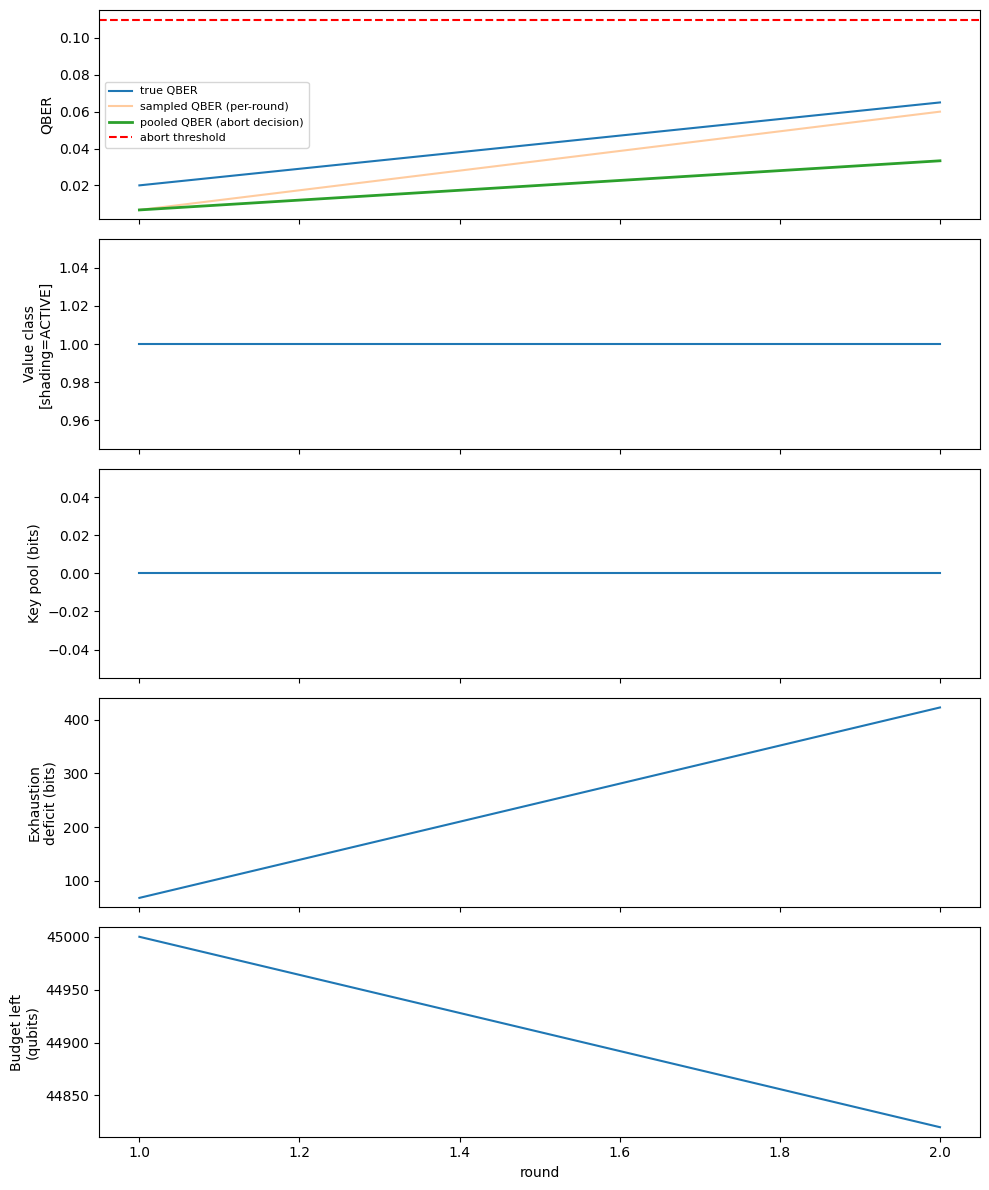


Saved: sanity_random_eve_trace_v2.png


In [15]:
# %% Cell 11 (REPLACED) — Sanity checks
cfg = EnvConfig(seed=0)

# Explicit calibration with diagnostics (see note in calibrate_cusum_threshold docstring)
cfg.cusum_threshold, cusum_diag = calibrate_cusum_threshold(
    cfg.qber_baseline, cfg.sample_size_qber, cfg.max_rounds, cfg.cusum_slack,
    n_calib_episodes=3000, return_diagnostics=True)
print(f"[sanity] calibrated CUSUM threshold: {cfg.cusum_threshold:.5f}")
print(f"[sanity] null-process max-stat diagnostics: {cusum_diag}")
print("[expect] frac_exactly_zero should be well below 1.0 (e.g. <0.7), and "
      "p50/p75/p90 should be spread out rather than all clustered near 0 -- "
      "otherwise the threshold is still degenerate.")

# NEW: explicit supply/demand balance check before running any episodes
def baseline_secure_bits_per_round(cfg, qber=None):
    qber = cfg.qber_baseline if qber is None else qber
    n_sifted = cfg.n_qubits_per_round * 0.5
    remaining = max(0, n_sifted - cfg.sample_size_qber)
    return remaining * secure_key_rate(qber)

supply0 = baseline_secure_bits_per_round(cfg)
print(f"\n[calibration check] baseline secure bits/round (f=0): {supply0:.1f}")
for vc in ValueClass:
    demand = CLASS_PARAMS[vc]["rate"] * cfg.key_bits_per_message
    print(f"  {vc.name:8s} demand/round: {demand:7.1f}  "
          f"net (supply-demand): {supply0-demand:+7.1f}")
print("[expect] LOW: surplus (pool builds) | NORMAL: near-balanced/mild deficit | "
      "HIGH: clear deficit (pool drains)")

# --- Random Eve ---
def make_random_policy(seed):
    return RandomEvePolicy(len(cfg.intercept_levels), np.random.default_rng(seed))

df_random = run_batch(cfg, make_random_policy, n_episodes=30, seed0=100)
print("\n=== Random Eve summary (30 episodes) ===")
print(df_random.describe().T[["mean", "std", "min", "max"]])
print(f"[explicit] Random Eve: hard_abort rate = {df_random['hard_abort'].mean():.3f}, "
      f"cusum_detected rate = {df_random['cusum_detected'].mean():.3f}")

# --- Calibrate & run Greedy Eve ---
calib_env = EveEnv(cfg)
calib_env.reset(seed=777)
rate_samples = []
for _ in range(cfg.max_rounds):
    _, _, done, info = calib_env.step(0)
    last_feat = calib_env.frame_buf[-1]
    rate_samples.append(dict(zip(calib_env.feature_names, last_feat))["traffic_rate_obs"])
    if done:
        break

greedy_policy_template = GreedyTrafficEvePolicy(cfg.intercept_levels, cfg.qber_abort)
greedy_policy_template.calibrate(np.array(rate_samples))
print(f"\n[sanity] greedy thresholds on traffic_rate_obs: {greedy_policy_template.thresholds}")

def make_greedy_policy(seed):
    return greedy_policy_template

df_greedy = run_batch(cfg, make_greedy_policy, n_episodes=30, seed0=100, is_greedy=True)
print("\n=== Greedy Traffic Eve summary (30 episodes) ===")
print(df_greedy.describe().T[["mean", "std", "min", "max"]])
print(f"[explicit] Greedy Eve: hard_abort rate = {df_greedy['hard_abort'].mean():.3f}, "
      f"cusum_detected rate = {df_greedy['cusum_detected'].mean():.3f}")

# --- Theoretical cross-checks ---
mean_f_random_unconstrained = np.mean(cfg.intercept_levels)
print(f"\n[check] mean intercept level if budget unconstrained: {mean_f_random_unconstrained:.3f}")
print(f"[check] implied instantaneous QBER at that f: "
      f"{cfg.qber_baseline + mean_f_random_unconstrained*QBER_SLOPE:.4f} (abort at {cfg.qber_abort})")
print("[check] -> episodes should now run MUCH longer (tens to ~300 rounds), "
      "with hard_abort becoming rare-ish rather than near-certain within 2-3 rounds.")

# --- Single-episode diagnostic plot (Random Eve) ---
policy = make_random_policy(seed=42)
_, log = run_episode(cfg, policy, seed=42)

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)
axes[0].plot(log["round"], log["true_qber"], label="true QBER")
axes[0].plot(log["round"], log["qber_hat"], alpha=0.4, label="sampled QBER (per-round)")
axes[0].plot(log["round"], log["pooled_qber"], label="pooled QBER (abort decision)", lw=2)
axes[0].axhline(cfg.qber_abort, color="red", ls="--", label="abort threshold")
axes[0].legend(fontsize=8); axes[0].set_ylabel("QBER")

regime_colors = log["regime"].map({0: "white", 1: "lightblue"})
for i in range(len(log) - 1):
    axes[1].axvspan(log["round"].iloc[i], log["round"].iloc[i+1], color=regime_colors.iloc[i], alpha=0.5)
axes[1].plot(log["round"], log["value_class"], drawstyle="steps-post")
axes[1].set_ylabel("Value class\n[shading=ACTIVE]")

axes[2].plot(log["round"], log["pool_level"])
axes[2].set_ylabel("Key pool (bits)")

axes[3].plot(log["round"], log["deficit"])
axes[3].set_ylabel("Exhaustion\ndeficit (bits)")

axes[4].plot(log["round"], log["budget_remaining"])
axes[4].set_ylabel("Budget left\n(qubits)")
axes[4].set_xlabel("round")

plt.tight_layout()
plt.savefig("sanity_random_eve_trace_v2.png", dpi=120)
plt.show()
print("\nSaved: sanity_random_eve_trace_v2.png")

In [16]:
# %% Cell 11b (REPLACED) — Constant-action sweep: empirically validate the CUSUM breakeven point
# Theory: CUSUM per-round drift(f) = f * QBER_SLOPE - cusum_slack.
# Breakeven f* = cusum_slack / QBER_SLOPE (negative drift below, positive above).
f_star_theory = cfg.cusum_slack / QBER_SLOPE
print(f"[theory] breakeven average interception f* = {f_star_theory:.4f} "
      f"(sustained f below this should rarely trigger CUSUM; above it, should "
      f"trigger with rising probability / falling survival time)")

class ConstantActionPolicy:
    """Diagnostic-only: always plays the same fixed action index every round."""
    def __init__(self, action_idx):
        self.action_idx = action_idx

    def act(self, obs):
        return self.action_idx

rows = []
for action_idx, f_level in enumerate(cfg.intercept_levels):
    def make_policy(seed, action_idx=action_idx):
        return ConstantActionPolicy(action_idx)
    df = run_batch(cfg, make_policy, n_episodes=30, seed0=200)
    rows.append(dict(
        action_idx=action_idx, f_level=f_level,
        mean_episode_length=df["episode_length"].mean(),
        frac_horizon_reached=(df["termination_reason"] == "horizon_reached").mean(),
        frac_cusum_terminated=(df["termination_reason"] == "cusum_detected").mean(),
        frac_hard_abort=(df["termination_reason"] == "hard_abort").mean(),
        frac_budget_exhausted=(df["termination_reason"] == "budget_exhausted").mean(),
        mean_budget_used_frac=df["budget_used_frac"].mean(),
        mean_reward=df["total_value_weighted_reward"].mean(),
    ))

breakeven_table = pd.DataFrame(rows)
print("\n=== Constant-action breakeven validation (30 episodes each) ===")
print(breakeven_table.to_string(index=False))
print(f"\n[expect] action 0 (f=0.0): ~all horizon_reached, ~0 detected.")
print(f"[expect] action near f*≈{f_star_theory:.3f}: mixed/borderline -- largely survives, "
      f"but not as cleanly as f=0.")
print(f"[expect] actions with f well ABOVE f*: frac_cusum_terminated rising sharply, "
      f"mean_episode_length dropping well below 300.")

[theory] breakeven average interception f* = 0.0480 (sustained f below this should rarely trigger CUSUM; above it, should trigger with rising probability / falling survival time)

=== Constant-action breakeven validation (30 episodes each) ===
 action_idx  f_level  mean_episode_length  frac_horizon_reached  frac_cusum_terminated  frac_hard_abort  frac_budget_exhausted  mean_budget_used_frac  mean_reward
          0     0.00           277.566667              0.866667               0.133333              0.0                    0.0               0.000000   -20.000000
          1     0.02           125.200000              0.200000               0.800000              0.0                    0.0               0.055644    19.060111
          2     0.04            24.866667              0.000000               1.000000              0.0                    0.0               0.022104  -103.473840
          3     0.06             8.366667              0.000000               1.000000              0.0 

=== CUSUM operating characteristic: ARL vs sustained interception f ===
    f  theoretical_drift  mean_episode_length  frac_cusum_terminated  frac_horizon_reached  frac_hard_abort
0.000           -0.01200               295.50                   0.02                  0.98             0.00
0.010           -0.00950               262.34                   0.24                  0.76             0.00
0.020           -0.00700               151.30                   0.78                  0.22             0.00
0.030           -0.00450                63.30                   1.00                  0.00             0.00
0.040           -0.00200                23.12                   1.00                  0.00             0.00
0.045           -0.00075                13.66                   1.00                  0.00             0.00
0.050            0.00050                10.10                   1.00                  0.00             0.00
0.055            0.00175                 8.86                   

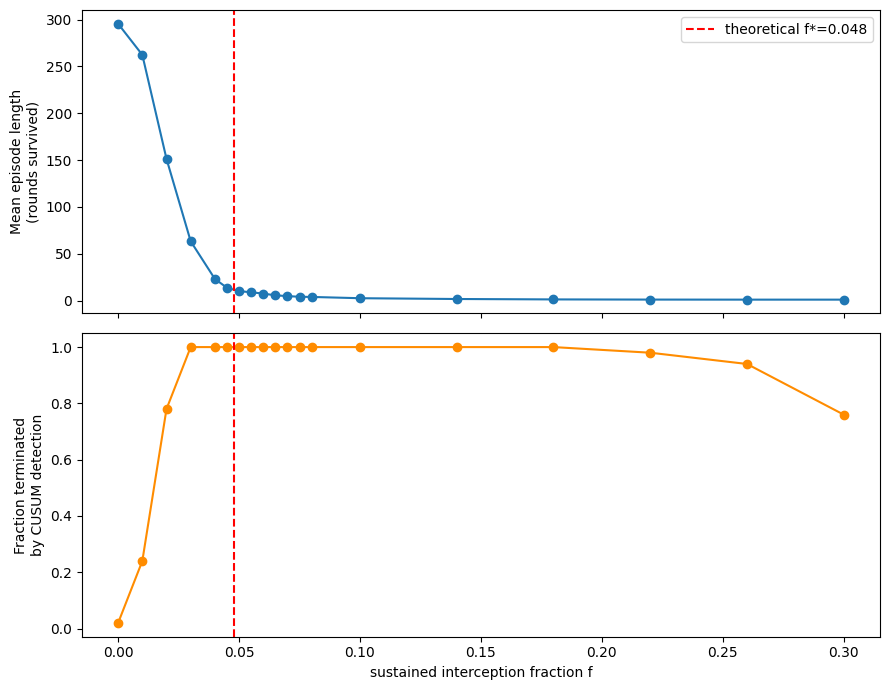


Saved: cusum_arl_operating_characteristic.png
[expect] a sharp transition zone right around f*, with mean_episode_length dropping from ~horizon-length to a small number of rounds over a narrow f range.


In [17]:
# %% Cell 11c — NEW: continuous ARL-vs-f sweep (detector operating characteristic)
# Characterizes CUSUM's average-run-length as a smooth function of sustained
# interception fraction f, independent of the discrete action grid. This is
# the "detector operating characteristic curve" -- validates the sharp
# knife-edge transition at f* and quantifies exactly how fast ARL collapses
# once f exceeds breakeven. Also useful as a standalone diagnostic
# figure/table for the eventual writeup.
import copy

f_sweep = np.concatenate([
    np.linspace(0.0, 0.04, 5),
    np.linspace(0.045, 0.08, 8),   # dense sampling right around breakeven
    np.linspace(0.10, 0.30, 6),
])
f_sweep = np.unique(np.round(f_sweep, 4))

n_episodes_arl = 50
arl_rows = []
for f in f_sweep:
    cfg_f = copy.deepcopy(cfg)
    cfg_f.intercept_levels = (f,)   # single always-on action, bypasses discrete grid entirely

    def make_const_policy(seed, f=f):
        return ConstantActionPolicy(0)

    df_f = run_batch(cfg_f, make_const_policy, n_episodes=n_episodes_arl, seed0=300)
    arl_rows.append(dict(
        f=f,
        theoretical_drift=f * QBER_SLOPE - cfg.cusum_slack,
        mean_episode_length=df_f["episode_length"].mean(),
        frac_cusum_terminated=(df_f["termination_reason"] == "cusum_detected").mean(),
        frac_horizon_reached=(df_f["termination_reason"] == "horizon_reached").mean(),
        frac_hard_abort=(df_f["termination_reason"] == "hard_abort").mean(),
    ))

arl_df = pd.DataFrame(arl_rows)
print("=== CUSUM operating characteristic: ARL vs sustained interception f ===")
print(arl_df.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(arl_df["f"], arl_df["mean_episode_length"], marker="o")
axes[0].axvline(f_star_theory, color="red", ls="--", label=f"theoretical f*={f_star_theory:.3f}")
axes[0].set_ylabel("Mean episode length\n(rounds survived)")
axes[0].legend()

axes[1].plot(arl_df["f"], arl_df["frac_cusum_terminated"], marker="o", color="darkorange")
axes[1].axvline(f_star_theory, color="red", ls="--")
axes[1].set_ylabel("Fraction terminated\nby CUSUM detection")
axes[1].set_xlabel("sustained interception fraction f")

plt.tight_layout()
plt.savefig("cusum_arl_operating_characteristic.png", dpi=120)
plt.show()
print("\nSaved: cusum_arl_operating_characteristic.png")
print("[expect] a sharp transition zone right around f*, with mean_episode_length "
      "dropping from ~horizon-length to a small number of rounds over a narrow f range.")

In [18]:
# %% Cell 11d — NEW: expected-value sanity check across constant strategies
# Confirms rescaled penalties allow a non-trivial policy to plausibly beat
# "always play safe" (action 0), i.e. that the reward landscape isn't
# degenerate before we invest in RL training.
rows = []
for action_idx, f_level in enumerate(cfg.intercept_levels):
    def make_policy(seed, action_idx=action_idx):
        return ConstantActionPolicy(action_idx)
    df = run_batch(cfg, make_policy, n_episodes=60, seed0=400)
    rows.append(dict(
        f_level=f_level,
        mean_reward=df["total_value_weighted_reward"].mean(),
        std_reward=df["total_value_weighted_reward"].std(),
        mean_episode_length=df["episode_length"].mean(),
        frac_survived_full_horizon=(df["termination_reason"] == "horizon_reached").mean(),
    ))

sanity_df = pd.DataFrame(rows)
print("=== Expected-value sanity check across constant strategies (60 episodes each) ===")
print(sanity_df.to_string(index=False))
print("\n[expect] at least one f>0 row should now have mean_reward competitive with "
      "or exceeding f=0's mean_reward -- confirming attacking isn't strictly "
      "dominated by caution under the rescaled penalty.")

=== Expected-value sanity check across constant strategies (60 episodes each) ===
 f_level  mean_reward  std_reward  mean_episode_length  frac_survived_full_horizon
    0.00    -7.500000   32.967627           292.083333                    0.950000
    0.02    25.506090  167.966932           139.983333                    0.216667
    0.04  -110.604992   43.953019            23.600000                    0.000000
    0.06  -137.376411   15.534318             7.883333                    0.000000
    0.10  -144.789407    5.632120             2.633333                    0.000000
    0.18  -147.111637    3.015213             1.266667                    0.000000
    0.30  -148.578176    2.163718             1.000000                    0.000000

[expect] at least one f>0 row should now have mean_reward competitive with or exceeding f=0's mean_reward -- confirming attacking isn't strictly dominated by caution under the rescaled penalty.


In [19]:
# %% Cell 12 — Gymnasium wrapper around EveEnv
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.utils import set_random_seed


class EveGymEnv(gym.Env):
    """
    Thin gymnasium.Env adapter around the validated EveEnv core. All physics/
    detection/hidden-state logic stays in EveEnv untouched; this wrapper only
    translates the calling convention and handles the terminated-vs-truncated
    distinction, which matters for correct value bootstrapping in PPO:

      - terminated=True : hard_abort, cusum_detected, budget_exhausted
        (a true absorbing state -- zero further reward is reachable, the
        episode is genuinely over)
      - truncated=True  : horizon_reached (an externally imposed session
        length limit -- more reward would have been possible with a longer
        horizon, so PPO should bootstrap the value function here rather than
        treating it as a true terminal state)
    """
    metadata = {"render_modes": []}

    def __init__(self, cfg: EnvConfig):
        super().__init__()
        self.core = EveEnv(cfg)
        self.action_space = spaces.Discrete(self.core.n_actions)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.core.obs_dim,), dtype=np.float32
        )

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)   # satisfies gymnasium's base-class seeding contract (sets self._np_random)
        obs = self.core.reset(seed=seed)  # actual simulator RNG/hidden-state reseeding happens here, unchanged
        return obs, {}

    def step(self, action):
        obs, reward, done, info = self.core.step(action)
        terminated = done and info["termination_reason"] in (
            "hard_abort", "cusum_detected", "budget_exhausted"
        )
        truncated = done and info["termination_reason"] == "horizon_reached"
        return obs, float(reward), bool(terminated), bool(truncated), info


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [20]:
# %% Cell 13 — Environment API sanity check
from gymnasium.utils.env_checker import check_env

cfg_check = EnvConfig(seed=0, obs_mode="full")
gym_env_check = EveGymEnv(cfg_check)
check_env(gym_env_check, warn=True, skip_render_check=True)
print("[sanity] gymnasium check_env passed with no exceptions.")


[sanity] gymnasium check_env passed with no exceptions.


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:367: UserWarning: WARN: `check_env(warn=...)` parameter is now ignored.
  logger.warn("`check_env(warn=...)` parameter is now ignored.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:311: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:315: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
  logger.warn(


In [21]:
# %% Cell 14 — Vec-env construction and PPO training helper
def make_training_vec_env(obs_mode: str, base_seed: int, delay_rounds: int = 0,
                           normalize_obs=True, normalize_reward=True):
    """
    Single-process DummyVecEnv (fine here -- this is a pure-Python analytic
    simulator, not a physics-heavy sim) wrapped in VecNormalize to handle the
    very different feature scales in the 'full' observation (qber_hat ~0.02-
    0.1, size_obs ~100-900, budget_frac 0-1, etc.) and the wide reward range
    we measured (std up to ~168 at f=0.02).

    IMPORTANT: SB3's auto-reset calls env.reset() with no seed at episode
    boundaries. Per EveEnv.reset()'s semantics, seed=None means the RNG and
    hidden Markov process are NOT reseeded between episodes -- they continue
    as one long stochastic stream. This is intentional: it gives the agent
    broad exposure to many different hidden-state trajectories over a long
    training run rather than replaying a small fixed set of seeded episodes.
    Evaluation, by contrast, always uses explicit fixed seeds (see
    evaluate_rl_policy below) so comparisons against the baselines remain
    apples-to-apples.
    """
    def _make():
        cfg = EnvConfig(seed=base_seed, obs_mode=obs_mode, delay_rounds=delay_rounds)
        env = EveGymEnv(cfg)
        env = Monitor(env)
        return env

    vec_env = DummyVecEnv([_make])
    vec_env = VecNormalize(vec_env, norm_obs=normalize_obs, norm_reward=normalize_reward,
                            clip_obs=10.0, clip_reward=20.0, gamma=0.995)
    return vec_env


def train_ppo_agent(obs_mode: str, total_timesteps: int, seed: int,
                     delay_rounds: int = 0, save_path: str = None, verbose=1):
    set_random_seed(seed)
    vec_env = make_training_vec_env(obs_mode, base_seed=seed, delay_rounds=delay_rounds)

    model = PPO(
        "MlpPolicy",
        vec_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.995,        # slightly above SB3 default 0.99 -- episodes run up to 300 rounds
        gae_lambda=0.95,
        ent_coef=0.01,      # small entropy bonus: encourage exploration given delayed/sparse detection risk
        verbose=verbose,
        seed=seed,
        policy_kwargs=dict(net_arch=[64, 64]),
    )
    model.learn(total_timesteps=total_timesteps)

    if save_path is not None:
        model.save(save_path)
        vec_env.save(save_path + "_vecnormalize.pkl")

    return model, vec_env

In [22]:
# %% Cell 15 — SMOKE TEST: short training runs
# NOT final results -- purely confirming the plumbing works end-to-end and
# some learning signal is present. Real experiments need far more timesteps
# (see Phase 2 continuation).
SMOKE_TEST_TIMESTEPS = 20_000

print("=== Smoke test: QBER-only agent ===")
model_qber_smoke, vecenv_qber_smoke = train_ppo_agent(
    obs_mode="qber_only", total_timesteps=SMOKE_TEST_TIMESTEPS, seed=1,
    delay_rounds=0, save_path=None, verbose=1
)

print("\n=== Smoke test: Messaging-aware agent ===")
model_full_smoke, vecenv_full_smoke = train_ppo_agent(
    obs_mode="full", total_timesteps=SMOKE_TEST_TIMESTEPS, seed=1,
    delay_rounds=0, save_path=None, verbose=1
)


=== Smoke test: QBER-only agent ===
Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.25     |
|    ep_rew_mean     | -144     |
| time/              |          |
|    fps             | 410      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 4.07       |
|    ep_rew_mean          | -144       |
| time/                   |            |
|    fps                  | 363        |
|    iterations           | 2          |
|    time_elapsed         | 11         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.02625721 |
|    clip_fraction        | 0.177      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.93      |
|    explained_variance   | -0.643     |
|    learning_rate        | 0.0003     |
|   

In [23]:
# %% Cell 16 — RL policy adapter + evaluation via the EXISTING run_batch harness
class RLPolicyAdapter:
    """
    Wraps a trained SB3 model (+ its frozen VecNormalize observation stats)
    so it plugs directly into run_episode/run_batch alongside Random/Greedy/
    ConstantAction policies -- guaranteeing IDENTICAL evaluation methodology
    (same seeded episodes, same metrics) across every agent type.
    """
    def __init__(self, model, vec_normalize: VecNormalize = None, deterministic=True):
        self.model = model
        self.vec_normalize = vec_normalize
        self.deterministic = deterministic

    def act(self, obs):
        obs_in = obs.reshape(1, -1).astype(np.float32)
        if self.vec_normalize is not None:
            obs_in = self.vec_normalize.normalize_obs(obs_in)
        action, _ = self.model.predict(obs_in, deterministic=self.deterministic)
        return int(action[0])


def evaluate_rl_policy(cfg: EnvConfig, model, vec_normalize, n_episodes=30, seed0=100):
    def make_policy(seed):
        return RLPolicyAdapter(model, vec_normalize, deterministic=True)
    return run_batch(cfg, make_policy, n_episodes=n_episodes, seed0=seed0, is_greedy=False)


print("=== Smoke test QBER-only agent: evaluation (30 episodes, seeds 100-129) ===")
df_qber_smoke_eval = evaluate_rl_policy(
    EnvConfig(seed=0, obs_mode="qber_only"), model_qber_smoke, vecenv_qber_smoke,
    n_episodes=30, seed0=100
)
print(df_qber_smoke_eval.describe().T[["mean", "std", "min", "max"]])
print(f"[explicit] termination breakdown:\n{df_qber_smoke_eval['termination_reason'].value_counts()}")

print("\n=== Smoke test Messaging-aware agent: evaluation (30 episodes, seeds 100-129) ===")
df_full_smoke_eval = evaluate_rl_policy(
    EnvConfig(seed=0, obs_mode="full"), model_full_smoke, vecenv_full_smoke,
    n_episodes=30, seed0=100
)
print(df_full_smoke_eval.describe().T[["mean", "std", "min", "max"]])
print(f"[explicit] termination breakdown:\n{df_full_smoke_eval['termination_reason'].value_counts()}")

print("\n=== Reference: baselines evaluated earlier ===")
print(f"Random Eve            mean_reward = {df_random['total_value_weighted_reward'].mean():.2f}")
print(f"Greedy Eve            mean_reward = {df_greedy['total_value_weighted_reward'].mean():.2f}")
print(f"Best constant f=0.02  mean_reward (60 eps, from sanity_df) = "
      f"{sanity_df.loc[sanity_df['f_level']==0.02, 'mean_reward'].values[0]:.2f}")

=== Smoke test QBER-only agent: evaluation (30 episodes, seeds 100-129) ===
                                    mean           std         min  \
total_value_weighted_reward   -96.535880  7.341682e+01 -149.163733   
total_qubits_intercepted     1021.333333  1.003771e+03   60.000000   
budget_used_frac                0.022696  2.230603e-02    0.001333   
mean_true_qber                  0.024932  2.518038e-03    0.020698   
max_true_qber                   0.035000  1.411503e-17    0.035000   
cusum_max                       0.027600  5.680106e-03    0.021333   
total_secure_bits_generated  8519.082082  8.332151e+03   73.853575   
total_exhaustion_deficit     4423.097900  5.411119e+03   86.146425   
episode_length                 62.800000  6.011850e+01    1.000000   

                                      max  
total_value_weighted_reward    245.893920  
total_qubits_intercepted      5480.000000  
budget_used_frac                 0.121778  
mean_true_qber                   0.035000  
max

In [24]:
# %% Cell 17 — Calibration run: how many timesteps until convergence?
import time

t0 = time.time()
model_qber_cal, vecenv_qber_cal = train_ppo_agent(
    obs_mode="qber_only", total_timesteps=200_000, seed=1,
    delay_rounds=0, save_path="qber_only_delay0_seed1_cal", verbose=0
)
print(f"200k-step calibration run took {time.time()-t0:.1f}s")

df_qber_cal_eval = evaluate_rl_policy(
    EnvConfig(seed=0, obs_mode="qber_only"), model_qber_cal, vecenv_qber_cal,
    n_episodes=50, seed0=100
)
print("\n=== 200k-step QBER-only agent: evaluation (50 episodes) ===")
print(df_qber_cal_eval.describe().T[["mean", "std", "min", "max"]])
print(f"[explicit] termination breakdown:\n{df_qber_cal_eval['termination_reason'].value_counts()}")
print(f"\n[compare] 20k-step checkpoint mean_reward was 40.6 -- is 200k meaningfully higher?")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# %% Cell 18 — Learning-curve training harness (periodic checkpoint + eval)
def train_ppo_with_learning_curve(obs_mode: str, seed: int, delay_rounds: int,
                                   total_timesteps: int, checkpoint_interval: int,
                                   eval_episodes: int = 30, eval_seed0: int = 100,
                                   ent_coef: float = 0.01, verbose_training=False):
    """
    Trains in chunks of `checkpoint_interval` steps, evaluating via the SAME
    run_batch harness used for all baselines after each chunk. Also pulls
    entropy_loss and explained_variance out of SB3's internal logger at each
    checkpoint -- these let us distinguish "converged" (entropy flatlined,
    reward flatlined) from "possibly stuck" (entropy STILL dropping while
    reward has flatlined, suggesting premature exploitation) from "still
    learning" (both still moving).
    """
    set_random_seed(seed)
    vec_env = make_training_vec_env(obs_mode, base_seed=seed, delay_rounds=delay_rounds)

    model = PPO(
        "MlpPolicy", vec_env,
        learning_rate=3e-4, n_steps=2048, batch_size=64, n_epochs=10,
        gamma=0.995, gae_lambda=0.95, ent_coef=ent_coef,
        verbose=1 if verbose_training else 0, seed=seed,
        policy_kwargs=dict(net_arch=[64, 64]),
    )

    n_checkpoints = total_timesteps // checkpoint_interval
    records = []
    steps_done = 0

    eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay_rounds)

    for i in range(n_checkpoints):
        model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
        steps_done += checkpoint_interval

        df_eval = evaluate_rl_policy(eval_cfg, model, vec_env,
                                      n_episodes=eval_episodes, seed0=eval_seed0)

        entropy_loss = model.logger.name_to_value.get("train/entropy_loss", np.nan)
        explained_var = model.logger.name_to_value.get("train/explained_variance", np.nan)

        rec = dict(
            obs_mode=obs_mode, seed=seed, delay_rounds=delay_rounds, timesteps=steps_done,
            mean_reward=df_eval["total_value_weighted_reward"].mean(),
            std_reward=df_eval["total_value_weighted_reward"].std(),
            mean_episode_length=df_eval["episode_length"].mean(),
            frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean(),
            frac_horizon_reached=(df_eval["termination_reason"] == "horizon_reached").mean(),
            mean_max_true_qber=df_eval["max_true_qber"].mean(),
            std_max_true_qber=df_eval["max_true_qber"].std(),
            entropy_loss=entropy_loss,
            explained_variance=explained_var,
        )
        records.append(rec)
        print(f"[{obs_mode} seed={seed} delay={delay_rounds}] steps={steps_done:>7} "
              f"reward={rec['mean_reward']:7.2f} ep_len={rec['mean_episode_length']:6.1f} "
              f"entropy={entropy_loss:.3f} exp_var={explained_var:.3f} "
              f"ceiling_qber={rec['mean_max_true_qber']:.4f}±{rec['std_max_true_qber']:.4f}")

    return model, vec_env, pd.DataFrame(records)

In [ ]:
# %% Cell 18b — REVISED training helper: multi-env, no reward normalization
from stable_baselines3.common.vec_env import SubprocVecEnv

import warnings
warnings.filterwarnings("ignore", message=".*Gym has been unmaintained.*")

def make_training_vec_env_v2(obs_mode: str, base_seed: int, delay_rounds: int = 0,
                              n_envs: int = 8, normalize_obs=True):
    """
    REVISED AGAIN: switched from SubprocVecEnv to DummyVecEnv. SubprocVecEnv
    spawns real OS subprocesses that were never being closed between grid
    iterations, leaking memory/processes across the training loop and
    crashing the Kaggle kernel after a few runs. DummyVecEnv steps all
    n_envs environments sequentially within ONE process -- no subprocess
    spawning, no leak risk, no Kaggle sandboxing concerns. We still get the
    batch-diversity benefit (multiple independent env instances contributing
    to each PPO rollout) that fixed the v1 training instability; we just
    lose OS-level parallelism, which barely mattered anyway since this
    simulator is a fast pure-NumPy analytic model, not an expensive physics
    sim -- the earlier ~45-55s/20k-steps timing was likely dominated by
    subprocess spawn overhead, not actual computation.
    """
    def _make(rank):
        def _init():
            cfg = EnvConfig(seed=base_seed + rank, obs_mode=obs_mode, delay_rounds=delay_rounds)
            env = EveGymEnv(cfg)
            env = Monitor(env)
            return env
        return _init

    vec_env = DummyVecEnv([_make(i) for i in range(n_envs)])
    vec_env = VecNormalize(vec_env, norm_obs=normalize_obs, norm_reward=False,
                            clip_obs=10.0, gamma=0.995)
    return vec_env


def train_ppo_with_learning_curve_v2(obs_mode: str, seed: int, delay_rounds: int,
                                      total_timesteps: int, checkpoint_interval: int,
                                      n_envs: int = 8, eval_episodes: int = 30,
                                      eval_seed0: int = 100, ent_coef: float = 0.01,
                                      verbose_training=False):
    set_random_seed(seed)
    vec_env = make_training_vec_env_v2(obs_mode, base_seed=seed, delay_rounds=delay_rounds,
                                        n_envs=n_envs)

    model = PPO(
        "MlpPolicy", vec_env,
        learning_rate=3e-4,
        n_steps=512,              # per-env rollout length; total batch = n_steps * n_envs = 4096
        batch_size=256,
        n_epochs=10,
        gamma=0.995, gae_lambda=0.95, ent_coef=ent_coef,
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=1 if verbose_training else 0, seed=seed,
        policy_kwargs=dict(net_arch=[64, 64]),
    )

    n_checkpoints = total_timesteps // checkpoint_interval
    records = []
    steps_done = 0
    eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay_rounds)

    for i in range(n_checkpoints):
        model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
        steps_done += checkpoint_interval

        df_eval = evaluate_rl_policy(eval_cfg, model, vec_env,
                                      n_episodes=eval_episodes, seed0=eval_seed0)

        entropy_loss = model.logger.name_to_value.get("train/entropy_loss", np.nan)
        explained_var = model.logger.name_to_value.get("train/explained_variance", np.nan)

        rec = dict(
            obs_mode=obs_mode, seed=seed, delay_rounds=delay_rounds, timesteps=steps_done,
            mean_reward=df_eval["total_value_weighted_reward"].mean(),
            std_reward=df_eval["total_value_weighted_reward"].std(),
            mean_episode_length=df_eval["episode_length"].mean(),
            frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean(),
            frac_horizon_reached=(df_eval["termination_reason"] == "horizon_reached").mean(),
            mean_max_true_qber=df_eval["max_true_qber"].mean(),
            std_max_true_qber=df_eval["max_true_qber"].std(),
            entropy_loss=entropy_loss,
            explained_variance=explained_var,
        )
        records.append(rec)
        print(f"[{obs_mode} seed={seed} delay={delay_rounds}] steps={steps_done:>7} "
              f"reward={rec['mean_reward']:7.2f} ep_len={rec['mean_episode_length']:6.1f} "
              f"entropy={entropy_loss:.3f} exp_var={explained_var:.3f} "
              f"ceiling_qber={rec['mean_max_true_qber']:.4f}±{rec['std_max_true_qber']:.4f}")

    return model, vec_env, pd.DataFrame(records)


In [ ]:
# %% Cell 19 — Run learning curves: 2 seeds x 2 obs_modes, delay=0 (preliminary, before full grid)
TOTAL_TIMESTEPS_CAL = 300_000
CHECKPOINT_INTERVAL = 30_000

learning_curve_results = []
trained_models = {}

for obs_mode in ["qber_only", "full"]:
    for seed in [1, 2]:
        print(f"\n{'='*70}\nTraining: obs_mode={obs_mode}, seed={seed}, delay=0\n{'='*70}")
        model, vec_env, df_curve = train_ppo_with_learning_curve(
            obs_mode=obs_mode, seed=seed, delay_rounds=0,
            total_timesteps=TOTAL_TIMESTEPS_CAL, checkpoint_interval=CHECKPOINT_INTERVAL,
            eval_episodes=30, eval_seed0=100,
        )
        learning_curve_results.append(df_curve)
        trained_models[(obs_mode, seed)] = (model, vec_env)

learning_curve_df = pd.concat(learning_curve_results, ignore_index=True)
learning_curve_df.to_csv("learning_curves_delay0_calibration.csv", index=False)
print("\nSaved: learning_curves_delay0_calibration.csv")

In [ ]:
# %% Cell 19b — Re-run calibration with the revised setup
learning_curve_results_v2 = []
trained_models_v2 = {}

for obs_mode in ["qber_only", "full"]:
    for seed in [1, 2]:
        print(f"\n{'='*70}\nTraining (v2): obs_mode={obs_mode}, seed={seed}, delay=0\n{'='*70}")
        model, vec_env, df_curve = train_ppo_with_learning_curve_v2(
            obs_mode=obs_mode, seed=seed, delay_rounds=0,
            total_timesteps=300_000, checkpoint_interval=30_000,
            n_envs=8, eval_episodes=30, eval_seed0=100,
        )
        learning_curve_results_v2.append(df_curve)
        trained_models_v2[(obs_mode, seed)] = (model, vec_env)

learning_curve_df_v2 = pd.concat(learning_curve_results_v2, ignore_index=True)
learning_curve_df_v2.to_csv("learning_curves_delay0_calibration_v2.csv", index=False)
print("\nSaved: learning_curves_delay0_calibration_v2.csv")

In [ ]:
# %% Cell 20 — Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for obs_mode, color in [("qber_only", "tab:blue"), ("full", "tab:orange")]:
    sub = learning_curve_df[learning_curve_df["obs_mode"] == obs_mode]
    for seed in sub["seed"].unique():
        s = sub[sub["seed"] == seed]
        axes[0,0].plot(s["timesteps"], s["mean_reward"], color=color, alpha=0.6,
                        marker='o', label=f"{obs_mode} seed={seed}")
        axes[0,1].plot(s["timesteps"], s["entropy_loss"], color=color, alpha=0.6, marker='o')
        axes[1,0].plot(s["timesteps"], s["explained_variance"], color=color, alpha=0.6, marker='o')
        axes[1,1].plot(s["timesteps"], s["mean_episode_length"], color=color, alpha=0.6, marker='o')

axes[0,0].axhline(25.5, color='gray', ls='--', label='constant f=0.02 baseline')
axes[0,0].set_title("Mean value-weighted reward"); axes[0,0].legend(fontsize=7)
axes[0,1].set_title("Entropy loss (less negative early = more exploration; "
                     "flatlining = policy has committed)")
axes[1,0].set_title("Explained variance (critic quality; should rise toward 1)")
axes[1,1].set_title("Mean episode length (survival)")
for ax in axes.flat:
    ax.set_xlabel("training timesteps"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves_delay0_calibration.png", dpi=120)
plt.show()
print("Saved: learning_curves_delay0_calibration.png")

In [ ]:
# %% Cell 20b — Plot v2 learning curves
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for obs_mode, color in [("qber_only", "tab:blue"), ("full", "tab:orange")]:
    sub = learning_curve_df_v2[learning_curve_df_v2["obs_mode"] == obs_mode]
    for seed in sub["seed"].unique():
        s = sub[sub["seed"] == seed]
        axes[0,0].plot(s["timesteps"], s["mean_reward"], color=color, alpha=0.6,
                        marker='o', label=f"{obs_mode} seed={seed}")
        axes[0,1].plot(s["timesteps"], s["entropy_loss"], color=color, alpha=0.6, marker='o')
        axes[1,0].plot(s["timesteps"], s["explained_variance"], color=color, alpha=0.6, marker='o')
        axes[1,1].plot(s["timesteps"], s["mean_episode_length"], color=color, alpha=0.6, marker='o')

axes[0,0].axhline(25.5, color='gray', ls='--', label='constant f=0.02 baseline')
axes[0,0].set_title("Mean value-weighted reward (v2: multi-env, no reward norm)")
axes[0,0].legend(fontsize=7)
axes[0,1].set_title("Entropy loss")
axes[1,0].set_title("Explained variance (should now stabilize higher)")
axes[1,1].set_title("Mean episode length (survival)")
for ax in axes.flat:
    ax.set_xlabel("training timesteps"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves_delay0_calibration_v2.png", dpi=120)
plt.show()
print("Saved: learning_curves_delay0_calibration_v2.png")

In [ ]:
# %% Cell 21 — Continue training the v2 models further (600k total), same checkpoint cadence
def continue_training_with_learning_curve(model, vec_env, obs_mode, seed, delay_rounds,
                                           additional_timesteps, checkpoint_interval,
                                           steps_already_done, eval_episodes=30, eval_seed0=100):
    records = []
    steps_done = steps_already_done
    eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay_rounds)
    n_checkpoints = additional_timesteps // checkpoint_interval

    for i in range(n_checkpoints):
        model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
        steps_done += checkpoint_interval

        df_eval = evaluate_rl_policy(eval_cfg, model, vec_env,
                                      n_episodes=eval_episodes, seed0=eval_seed0)

        entropy_loss = model.logger.name_to_value.get("train/entropy_loss", np.nan)
        explained_var = model.logger.name_to_value.get("train/explained_variance", np.nan)
        value_loss = model.logger.name_to_value.get("train/value_loss", np.nan)

        rec = dict(
            obs_mode=obs_mode, seed=seed, delay_rounds=delay_rounds, timesteps=steps_done,
            mean_reward=df_eval["total_value_weighted_reward"].mean(),
            std_reward=df_eval["total_value_weighted_reward"].std(),
            mean_episode_length=df_eval["episode_length"].mean(),
            frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean(),
            frac_horizon_reached=(df_eval["termination_reason"] == "horizon_reached").mean(),
            entropy_loss=entropy_loss, explained_variance=explained_var, value_loss=value_loss,
        )
        records.append(rec)
        print(f"[{obs_mode} seed={seed} delay={delay_rounds}] steps={steps_done:>7} "
              f"reward={rec['mean_reward']:7.2f} ep_len={rec['mean_episode_length']:6.1f} "
              f"entropy={entropy_loss:.3f} exp_var={explained_var:.3f} vf_loss={value_loss:.4f}")

    return pd.DataFrame(records)


continued_results = []
for (obs_mode, seed), (model, vec_env) in trained_models_v2.items():
    print(f"\n{'='*70}\nContinuing: obs_mode={obs_mode}, seed={seed}\n{'='*70}")
    df_cont = continue_training_with_learning_curve(
        model, vec_env, obs_mode=obs_mode, seed=seed, delay_rounds=0,
        additional_timesteps=300_000, checkpoint_interval=30_000,
        steps_already_done=300_000, eval_episodes=30, eval_seed0=100,
    )
    continued_results.append(df_cont)

learning_curve_df_v2_extended = pd.concat(
    [learning_curve_df_v2] + continued_results, ignore_index=True
)
learning_curve_df_v2_extended.to_csv("learning_curves_delay0_calibration_v2_extended.csv", index=False)
print("\nSaved: learning_curves_delay0_calibration_v2_extended.csv")

In [ ]:
# %% Cell 21b — Convergence check at delay=50 before committing the full grid budget
model_d50, vecenv_d50, curve_d50 = train_ppo_with_learning_curve_v2(
    obs_mode="full", seed=1, delay_rounds=50,
    total_timesteps=600_000, checkpoint_interval=30_000,
    n_envs=8, eval_episodes=30, eval_seed0=100,
)
curve_d50.to_csv("learning_curve_delay50_seed1_full.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(curve_d50["timesteps"], curve_d50["mean_reward"], marker="o")
ax[0].set_title("delay=50: mean reward vs timesteps"); ax[0].grid(alpha=0.3)
ax[1].plot(curve_d50["timesteps"], curve_d50["explained_variance"], marker="o", label="explained_variance")
ax[1].plot(curve_d50["timesteps"], -curve_d50["entropy_loss"], marker="o", label="-entropy_loss")
ax[1].axvline(400_000, color="red", ls="--", label="planned grid budget")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_title("Convergence diagnostics")
plt.tight_layout(); plt.savefig("convergence_check_delay50.png", dpi=120); plt.show()

print("[decision] if reward/explained_variance are still rising at the red line, "
      "bump GRID_TIMESTEPS in Cell 22, or use a delay-dependent budget.")

In [ ]:
# %% Cell 22 — Full experimental grid: setup and constants
import os
import json
import time
from scipy import stats as scipy_stats

# --- QUICK-TEST TOGGLE ---
# Set True first to validate the entire pipeline (dirs, resumability, CSV
# writing, plotting) end-to-end in a few minutes with tiny budgets. Once
# confirmed working, set False and rerun for the real experiment.
QUICK_TEST = True

if QUICK_TEST:
    GRID_TIMESTEPS = 20_000
    GRID_SEEDS = [1, 2]
    GRID_EVAL_EPISODES = 15
    print("[QUICK_TEST=True] Using tiny budgets to validate pipeline plumbing only. "
          "Results from this pass are NOT meaningful -- rerun with QUICK_TEST=False for real results.")
else:
    GRID_TIMESTEPS = 400_000
    GRID_SEEDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   # 10 seeds for a defensible headline claim
    GRID_EVAL_EPISODES = 50
    print("[QUICK_TEST=False] Full experimental budget -- this will take a long time. See wall-clock estimate.")

# Delay conditions, justified from Phase-1 validated trace: the natural
# pool build-up/drawdown cycle observed under the validated dynamics spanned
# roughly 40-50 rounds (calm accumulation) followed by a comparable drain
# during HIGH-value bursts. We pick:
#   0  -> no buffering (attack-time == consumption-time; near-bandit regime)
#   15 -> moderate buffering (~1/3 of the natural cycle length)
#   50 -> large buffering (~matches the natural full cycle length)
DELAY_CONDITIONS = [0, 15, 50]
OBS_MODES = ["qber_only", "full"]

CHECKPOINT_INTERVAL = 30_000 if not QUICK_TEST else 10_000
N_ENVS = 8
EVAL_SEED0 = 100
BASELINE_PSEUDO_SEEDS = [100, 200, 300, 400, 500]  # 5 independent episode-batches, mirrors 5 RL seeds

MODEL_DIR = "models"
RESULTS_DIR = "results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RL_RESULTS_CSV = os.path.join(RESULTS_DIR, f"rl_grid_results{'_quicktest' if QUICK_TEST else ''}.csv")
BASELINE_RESULTS_CSV = os.path.join(RESULTS_DIR, f"baseline_grid_results{'_quicktest' if QUICK_TEST else ''}.csv")

print(f"Grid: {len(OBS_MODES)} obs_modes x {len(DELAY_CONDITIONS)} delays x {len(GRID_SEEDS)} seeds "
      f"= {len(OBS_MODES)*len(DELAY_CONDITIONS)*len(GRID_SEEDS)} training runs, "
      f"{GRID_TIMESTEPS} steps each")

In [ ]:
# %% Cell 23 — Resumable train-or-load with model persistence
def model_paths(obs_mode, delay, seed):
    tag = f"{obs_mode}_delay{delay}_seed{seed}{'_quicktest' if QUICK_TEST else ''}"
    return (os.path.join(MODEL_DIR, f"{tag}.zip"),
            os.path.join(MODEL_DIR, f"{tag}_vecnorm.pkl"),
            os.path.join(MODEL_DIR, f"{tag}_meta.json"))


def train_or_load_agent(obs_mode, delay, seed, total_timesteps, checkpoint_interval,
                        n_envs=N_ENVS, force_retrain=False):
    """
    Trains a fresh PPO agent for (obs_mode, delay, seed) using the validated
    v2 recipe (multi-env, no reward normalization), OR loads a previously
    completed run from disk if one exists -- making the full grid safely
    resumable across multiple sessions / crashes.
    """
    model_path, vecnorm_path, meta_path = model_paths(obs_mode, delay, seed)

    if (not force_retrain) and os.path.exists(model_path) and os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
        if meta.get("total_timesteps") == total_timesteps:
            print(f"[SKIP] Found completed run: obs_mode={obs_mode} delay={delay} seed={seed}")
            vec_env = make_training_vec_env_v2(obs_mode, base_seed=seed, delay_rounds=delay, n_envs=1)
            vec_env = VecNormalize.load(vecnorm_path, vec_env)
            vec_env.training = False
            model = PPO.load(model_path)
            return model, vec_env, meta["learning_curve"]

    print(f"[TRAIN] obs_mode={obs_mode} delay={delay} seed={seed} -> {total_timesteps} steps")
    t0 = time.time()
    set_random_seed(seed)
    vec_env = make_training_vec_env_v2(obs_mode, base_seed=seed, delay_rounds=delay, n_envs=n_envs)

    model = PPO(
        "MlpPolicy", vec_env,
        learning_rate=3e-4, n_steps=512, batch_size=256, n_epochs=10,
        gamma=0.995, gae_lambda=0.95, ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5,
        verbose=0, seed=seed, policy_kwargs=dict(net_arch=[64, 64]),
    )

    n_checkpoints = max(1, total_timesteps // checkpoint_interval)
    learning_curve = []
    eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay)
    steps_done = 0

    def _check_action_collapse(model, vec_env, cfg, n_episodes=10, seed0=EVAL_SEED0):
        counts = np.zeros(len(cfg.intercept_levels))
        for i in range(n_episodes):
            env = EveEnv(cfg)
            obs = env.reset(seed=seed0 + i)
            done = False
            while not done:
                obs_in = vec_env.normalize_obs(obs.reshape(1, -1).astype(np.float32))
                a, _ = model.predict(obs_in, deterministic=True)
                counts[int(a[0])] += 1
                obs, r, done, info = env.step(int(a[0]))
        total = counts.sum()
        return counts / total if total > 0 else counts

    for i in range(n_checkpoints):
        model.learn(total_timesteps=checkpoint_interval, reset_num_timesteps=False)
        steps_done += checkpoint_interval
        df_eval = evaluate_rl_policy(eval_cfg, model, vec_env, n_episodes=20, seed0=EVAL_SEED0)

        entropy_loss = model.logger.name_to_value.get("train/entropy_loss", np.nan)
        explained_var = model.logger.name_to_value.get("train/explained_variance", np.nan)
        value_loss = model.logger.name_to_value.get("train/value_loss", np.nan)
        action_dist = _check_action_collapse(model, vec_env, eval_cfg, n_episodes=10)
        dominant_frac = float(action_dist.max())

        learning_curve.append(dict(
            timesteps=steps_done,
            mean_reward=float(df_eval["total_value_weighted_reward"].mean()),
            std_reward=float(df_eval["total_value_weighted_reward"].std()),
            frac_cusum_detected=float((df_eval["termination_reason"] == "cusum_detected").mean()),
            entropy_loss=None if np.isnan(entropy_loss) else float(entropy_loss),
            explained_variance=None if np.isnan(explained_var) else float(explained_var),
            value_loss=None if np.isnan(value_loss) else float(value_loss),
            dominant_action_frac=dominant_frac,
        ))
        if i == n_checkpoints - 1 and dominant_frac > 0.95:
            print(f"  [WARNING] policy may have collapsed: {dominant_frac:.2f} mass on one action "
                  f"(dist={np.round(action_dist,3)})")

    elapsed = time.time() - t0
    print(f"  done in {elapsed:.0f}s, final reward={learning_curve[-1]['mean_reward']:.2f}, "
          f"dominant_action_frac={learning_curve[-1]['dominant_action_frac']:.2f}")

    model.save(model_path)
    vec_env.save(vecnorm_path)
    with open(meta_path, "w") as f:
        json.dump(dict(obs_mode=obs_mode, delay=delay, seed=seed,
                        total_timesteps=total_timesteps, elapsed_seconds=elapsed,
                        learning_curve=learning_curve), f, indent=2)

    return model, vec_env, learning_curve

In [ ]:
# %% Cell 24 — Full training grid driver (resumable, writes results incrementally)
grid_final_results = []
grid_start_time = time.time()

import gc

for obs_mode in OBS_MODES:
    for delay in DELAY_CONDITIONS:
        for seed in GRID_SEEDS:
            model, vec_env, curve = train_or_load_agent(
                obs_mode, delay, seed, GRID_TIMESTEPS, CHECKPOINT_INTERVAL, n_envs=N_ENVS
            )

            # Final evaluation with the FULL eval episode count (used for actual results)
            eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay)
            df_eval = evaluate_rl_policy(eval_cfg, model, vec_env,
                                          n_episodes=GRID_EVAL_EPISODES, seed0=EVAL_SEED0)

            grid_final_results.append(dict(
                agent="RL", obs_mode=obs_mode, delay=delay, seed=seed,
                mean_reward=df_eval["total_value_weighted_reward"].mean(),
                std_reward=df_eval["total_value_weighted_reward"].std(),
                mean_episode_length=df_eval["episode_length"].mean(),
                frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean(),
                frac_horizon_reached=(df_eval["termination_reason"] == "horizon_reached").mean(),
                frac_hard_abort=(df_eval["termination_reason"] == "hard_abort").mean(),
                n_eval_episodes=GRID_EVAL_EPISODES,
            ))

            # Write incrementally after EVERY run so partial progress survives a crash
            pd.DataFrame(grid_final_results).to_csv(RL_RESULTS_CSV, index=False)

            # NEW: explicit cleanup -- prevents memory buildup across 30 grid iterations
            # even though DummyVecEnv no longer leaks OS processes like SubprocVecEnv did.
            vec_env.close()
            del model, vec_env
            gc.collect()
            
total_grid_time = time.time() - grid_start_time
print(f"\n=== Full RL grid complete in {total_grid_time/60:.1f} minutes ===")
rl_grid_df = pd.DataFrame(grid_final_results)
print(rl_grid_df.groupby(["obs_mode", "delay"])["mean_reward"].agg(["mean", "std", "count"]))



In [ ]:
# %% Cell 24b — Policy collapse / degeneracy diagnostic
def action_histogram(model_path, vecnorm_path, cfg, n_episodes=10, seed0=100):
    vec_env = make_training_vec_env_v2(cfg.obs_mode, base_seed=0, delay_rounds=cfg.delay_rounds, n_envs=1)
    vec_env = VecNormalize.load(vecnorm_path, vec_env)
    vec_env.training = False
    model = PPO.load(model_path)

    counts = np.zeros(len(cfg.intercept_levels))
    for i in range(n_episodes):
        env = EveEnv(cfg)
        obs = env.reset(seed=seed0 + i)
        done = False
        while not done:
            obs_in = obs.reshape(1, -1).astype(np.float32)
            obs_in = vec_env.normalize_obs(obs_in)
            a, _ = model.predict(obs_in, deterministic=True)
            counts[int(a[0])] += 1
            obs, r, done, info = env.step(int(a[0]))
    vec_env.close()
    return counts / counts.sum()

print("=== Action distribution check: delay=50 models ===")
for obs_mode in ["qber_only", "full"]:
    for seed in GRID_SEEDS:
        model_path, vecnorm_path, _ = model_paths(obs_mode, 50, seed)
        cfg_diag = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=50)
        dist = action_histogram(model_path, vecnorm_path, cfg_diag, n_episodes=15, seed0=100)
        flag = "  <-- COLLAPSED" if dist.max() > 0.90 else ""
        print(f"{obs_mode:10s} seed={seed}: {np.round(dist,3)}  (dominant={dist.max():.2f}){flag}")

In [ ]:
# %% Cell 24c — Risk-matched Pareto sweep: retrain at several penalty weightings
PENALTY_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]
PARETO_DELAYS = DELAY_CONDITIONS
PARETO_SEEDS = GRID_SEEDS[:3]
PARETO_TIMESTEPS = GRID_TIMESTEPS
PARETO_CHECKPOINT = CHECKPOINT_INTERVAL

def model_paths_pareto(obs_mode, delay, seed, mult):
    tag = f"{obs_mode}_delay{delay}_seed{seed}_pen{mult}{'_quicktest' if QUICK_TEST else ''}"
    return (os.path.join(MODEL_DIR, f"{tag}.zip"),
            os.path.join(MODEL_DIR, f"{tag}_vecnorm.pkl"),
            os.path.join(MODEL_DIR, f"{tag}_meta.json"))

def train_or_load_agent_pareto(obs_mode, delay, seed, mult, total_timesteps,
                                checkpoint_interval, n_envs=N_ENVS, force_retrain=False):
    model_path, vecnorm_path, meta_path = model_paths_pareto(obs_mode, delay, seed, mult)
    if (not force_retrain) and os.path.exists(model_path) and os.path.exists(meta_path):
        vec_env = make_training_vec_env_v2(obs_mode, base_seed=seed, delay_rounds=delay, n_envs=1)
        vec_env = VecNormalize.load(vecnorm_path, vec_env)
        vec_env.training = False
        return PPO.load(model_path), vec_env

    base_abort = EnvConfig().abort_penalty
    base_cusum = EnvConfig().cusum_detect_penalty

    def _make(rank):
        def _init():
            cfg = EnvConfig(seed=seed + rank, obs_mode=obs_mode, delay_rounds=delay,
                             abort_penalty=base_abort * mult, cusum_detect_penalty=base_cusum * mult)
            return Monitor(EveGymEnv(cfg))
        return _init

    set_random_seed(seed)
    vec_env = DummyVecEnv([_make(i) for i in range(n_envs)])
    vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.0, gamma=0.995)
    model = PPO("MlpPolicy", vec_env, learning_rate=3e-4, n_steps=512, batch_size=256,
                n_epochs=10, gamma=0.995, gae_lambda=0.95, ent_coef=0.01, vf_coef=0.5,
                max_grad_norm=0.5, verbose=0, seed=seed, policy_kwargs=dict(net_arch=[64, 64]))
    model.learn(total_timesteps=total_timesteps)
    model.save(model_path); vec_env.save(vecnorm_path)
    with open(meta_path, "w") as f:
        json.dump(dict(obs_mode=obs_mode, delay=delay, seed=seed, mult=mult,
                        total_timesteps=total_timesteps), f)
    return model, vec_env

pareto_rows = []
default_abort = EnvConfig().abort_penalty
default_cusum = EnvConfig().cusum_detect_penalty
for obs_mode in OBS_MODES:
    for delay in PARETO_DELAYS:
        for mult in PENALTY_MULTIPLIERS:
            for seed in PARETO_SEEDS:
                model, vec_env = train_or_load_agent_pareto(
                    obs_mode, delay, seed, mult, PARETO_TIMESTEPS, PARETO_CHECKPOINT)
                # evaluate with DEFAULT penalties so the scoring metric is comparable
                eval_cfg = EnvConfig(seed=0, obs_mode=obs_mode, delay_rounds=delay,
                                      abort_penalty=default_abort, cusum_detect_penalty=default_cusum)
                df_eval = evaluate_rl_policy(eval_cfg, model, vec_env,
                                              n_episodes=GRID_EVAL_EPISODES, seed0=EVAL_SEED0)
                pareto_rows.append(dict(
                    obs_mode=obs_mode, delay=delay, mult=mult, seed=seed,
                    mean_reward=df_eval["total_value_weighted_reward"].mean(),
                    frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean(),
                ))
                vec_env.close(); del model, vec_env; gc.collect()
        pd.DataFrame(pareto_rows).to_csv(os.path.join(RESULTS_DIR, "pareto_sweep.csv"), index=False)

pareto_df = pd.DataFrame(pareto_rows)
print(pareto_df.groupby(["obs_mode", "delay", "mult"])[["mean_reward", "frac_cusum_detected"]].mean())

In [ ]:
# %% Cell 25 — Baseline evaluation at matched conditions (Random, Greedy, best-constant per delay)
baseline_results = []

for delay in DELAY_CONDITIONS:
    cfg_delay = EnvConfig(seed=0, obs_mode="full", delay_rounds=delay)

    # --- Recalibrate Greedy thresholds for this delay (traffic generation is
    # delay-independent, but recalibrating is cheap and avoids subtle assumptions) ---
    calib_env = EveEnv(cfg_delay)
    calib_env.reset(seed=777)
    rate_samples = []
    for _ in range(cfg_delay.max_rounds):
        _, _, done, info = calib_env.step(0)
        last_feat = calib_env.frame_buf[-1]
        rate_samples.append(dict(zip(calib_env.feature_names, last_feat))["traffic_rate_obs"])
        if done:
            break
    greedy_policy_d = GreedyTrafficEvePolicy(cfg_delay.intercept_levels, cfg_delay.qber_abort)
    greedy_policy_d.calibrate(np.array(rate_samples))

    # --- Best constant action for this delay (sweep once, using pseudo-seed 100 batch) ---
    const_scores = []
    for action_idx, f_level in enumerate(cfg_delay.intercept_levels):
        def make_c(seed, action_idx=action_idx):
            return ConstantActionPolicy(action_idx)
        df_c = run_batch(cfg_delay, make_c, n_episodes=GRID_EVAL_EPISODES, seed0=100)
        const_scores.append((action_idx, f_level, df_c["total_value_weighted_reward"].mean()))
    best_action_idx, best_f, _ = max(const_scores, key=lambda x: x[2])
    print(f"[delay={delay}] best constant action: idx={best_action_idx} (f={best_f})")

    for pseudo_seed in BASELINE_PSEUDO_SEEDS:
        def make_random(seed):
            return RandomEvePolicy(len(cfg_delay.intercept_levels), np.random.default_rng(seed))
        df_r = run_batch(cfg_delay, make_random, n_episodes=GRID_EVAL_EPISODES, seed0=pseudo_seed)
        baseline_results.append(dict(
            agent="Random", delay=delay, pseudo_seed=pseudo_seed,
            mean_reward=df_r["total_value_weighted_reward"].mean(),
            mean_episode_length=df_r["episode_length"].mean(),
            frac_cusum_detected=(df_r["termination_reason"] == "cusum_detected").mean(),
        ))

        def make_g(seed):
            return greedy_policy_d
        df_g = run_batch(cfg_delay, make_g, n_episodes=GRID_EVAL_EPISODES, seed0=pseudo_seed, is_greedy=True)
        baseline_results.append(dict(
            agent="Greedy", delay=delay, pseudo_seed=pseudo_seed,
            mean_reward=df_g["total_value_weighted_reward"].mean(),
            mean_episode_length=df_g["episode_length"].mean(),
            frac_cusum_detected=(df_g["termination_reason"] == "cusum_detected").mean(),
        ))

        def make_bc(seed, action_idx=best_action_idx):
            return ConstantActionPolicy(action_idx)
        df_bc = run_batch(cfg_delay, make_bc, n_episodes=GRID_EVAL_EPISODES, seed0=pseudo_seed)
        baseline_results.append(dict(
            agent=f"BestConstant(f={best_f})", delay=delay, pseudo_seed=pseudo_seed,
            mean_reward=df_bc["total_value_weighted_reward"].mean(),
            mean_episode_length=df_bc["episode_length"].mean(),
            frac_cusum_detected=(df_bc["termination_reason"] == "cusum_detected").mean(),
        ))

    pd.DataFrame(baseline_results).to_csv(BASELINE_RESULTS_CSV, index=False)

baseline_df = pd.DataFrame(baseline_results)
print("\n=== Baseline grid complete ===")
print(baseline_df.groupby(["agent", "delay"])["mean_reward"].agg(["mean", "std", "count"]))


In [ ]:
# %% Cell 26 — Statistical aggregation: mean +/- 95% CI (t-distribution, small n)
def summarize_with_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    if n < 2:
        return mean, np.nan, np.nan
    sem = values.std(ddof=1) / np.sqrt(n)
    t_crit = scipy_stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin = t_crit * sem
    return mean, mean - margin, mean + margin


summary_rows = []

for obs_mode in OBS_MODES:
    for delay in DELAY_CONDITIONS:
        vals = rl_grid_df[(rl_grid_df.obs_mode == obs_mode) & (rl_grid_df.delay == delay)]["mean_reward"].values
        mean, lo, hi = summarize_with_ci(vals)
        summary_rows.append(dict(agent=obs_mode, delay=delay, mean_reward=mean,
                                  ci_lo=lo, ci_hi=hi, n=len(vals)))

for agent in baseline_df["agent"].unique():
    for delay in DELAY_CONDITIONS:
        sub = baseline_df[(baseline_df.agent == agent) & (baseline_df.delay == delay)]
        vals = sub["mean_reward"].values
        mean, lo, hi = summarize_with_ci(vals)
        summary_rows.append(dict(agent=agent, delay=delay, mean_reward=mean,
                                  ci_lo=lo, ci_hi=hi, n=len(vals)))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, f"summary_with_ci{'_quicktest' if QUICK_TEST else ''}.csv"), index=False)
print("\n=== Summary: mean reward +/- 95% CI, per agent per delay ===")
print(summary_df.to_string(index=False))



In [ ]:
# %% Cell 26b — Matched-risk comparison via Pareto-frontier interpolation
TARGET_DETECTION_RISK = 0.10

def interpolate_at_risk(df, target_risk):
    d = df.groupby("mult")[["mean_reward", "frac_cusum_detected"]].mean().sort_values("frac_cusum_detected")
    x, y = d["frac_cusum_detected"].values, d["mean_reward"].values
    if target_risk <= x.min(): return y[0]
    if target_risk >= x.max(): return y[-1]
    return float(np.interp(target_risk, x, y))

matched_rows = []
for obs_mode in OBS_MODES:
    for delay in PARETO_DELAYS:
        sub = pareto_df[(pareto_df.obs_mode == obs_mode) & (pareto_df.delay == delay)]
        matched_rows.append(dict(obs_mode=obs_mode, delay=delay,
                                  reward_at_matched_risk=interpolate_at_risk(sub, TARGET_DETECTION_RISK)))

matched_df = pd.DataFrame(matched_rows)
print(matched_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
for obs_mode, color in [("qber_only", "tab:blue"), ("full", "tab:orange")]:
    sub = matched_df[matched_df.obs_mode == obs_mode].sort_values("delay")
    ax.plot(sub["delay"], sub["reward_at_matched_risk"], marker="o", label=obs_mode, color=color)
ax.set_xlabel("buffering delay"); ax.set_ylabel(f"reward @ {TARGET_DETECTION_RISK:.0%} detection risk")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "matched_risk_comparison.png"), dpi=130); plt.show()

In [ ]:
# %% Cell 27 — Central hypothesis plot: does the messaging-aware advantage grow with delay?
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left panel: all agents, grouped bars per delay
agents_to_plot = ["qber_only", "full", "Random", "Greedy"] + \
    [a for a in summary_df["agent"].unique() if a.startswith("BestConstant")]
colors = plt.cm.tab10(np.linspace(0, 1, len(agents_to_plot)))

width = 0.8 / len(agents_to_plot)
x = np.arange(len(DELAY_CONDITIONS))
for i, agent in enumerate(agents_to_plot):
    sub = summary_df[summary_df.agent == agent].set_index("delay").reindex(DELAY_CONDITIONS)
    means = sub["mean_reward"].values
    errs = np.abs(sub[["ci_lo", "ci_hi"]].values.T - means)
    errs = np.nan_to_num(errs)
    axes[0].bar(x + i*width - 0.4 + width/2, means, width, yerr=errs, capsize=3,
                label=agent, color=colors[i])
axes[0].set_xticks(x); axes[0].set_xticklabels([f"delta={d}" for d in DELAY_CONDITIONS])
axes[0].set_ylabel("mean value-weighted reward")
axes[0].set_title("All agents vs buffering delay")
axes[0].legend(fontsize=7, ncol=2)
axes[0].axhline(0, color='black', lw=0.5)

# Right panel: THE central hypothesis -- (full - qber_only) advantage vs delay
advantage_rows = []
for delay in DELAY_CONDITIONS:
    full_vals = rl_grid_df[(rl_grid_df.obs_mode == "full") & (rl_grid_df.delay == delay)]["mean_reward"].values
    qber_vals = rl_grid_df[(rl_grid_df.obs_mode == "qber_only") & (rl_grid_df.delay == delay)]["mean_reward"].values
    # paired-by-seed-index advantage (seed i of 'full' vs seed i of 'qber_only')
    n = min(len(full_vals), len(qber_vals))
    diffs = full_vals[:n] - qber_vals[:n]
    mean, lo, hi = summarize_with_ci(diffs)
    advantage_rows.append(dict(delay=delay, mean_advantage=mean, ci_lo=lo, ci_hi=hi))

adv_df = pd.DataFrame(advantage_rows)
axes[1].errorbar(adv_df["delay"], adv_df["mean_advantage"],
                  yerr=[adv_df["mean_advantage"]-adv_df["ci_lo"], adv_df["ci_hi"]-adv_df["mean_advantage"]],
                  marker='o', capsize=4, color='darkred', linewidth=2)
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel("buffering delay (rounds)")
axes[1].set_ylabel("advantage: full - qber_only\n(mean reward, paired by seed)")
axes[1].set_title("CENTRAL HYPOTHESIS:\ndoes messaging-awareness help MORE as delay grows?")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"central_hypothesis{'_quicktest' if QUICK_TEST else ''}.png"), dpi=130)
plt.show()

print("\n=== Advantage table (full - qber_only, paired by seed) ===")
print(adv_df.to_string(index=False))
print("\n[interpretation] If the hypothesis holds, mean_advantage should be near "
      "zero (CI straddling 0) at delta=0, and increasingly positive with wider CI "
      "excluding 0 as delta grows. If advantage is flat/near-zero across all delta, "
      "that's a legitimate negative result worth reporting honestly.")

In [ ]:
# %% Cell 27b — Paired Wilcoxon signed-rank test + Holm-Bonferroni correction
from scipy.stats import wilcoxon

wilcoxon_rows = []
for delay in DELAY_CONDITIONS:
    full_vals = rl_grid_df[(rl_grid_df.obs_mode == "full") & (rl_grid_df.delay == delay)]["mean_reward"].values
    qber_vals = rl_grid_df[(rl_grid_df.obs_mode == "qber_only") & (rl_grid_df.delay == delay)]["mean_reward"].values
    n = min(len(full_vals), len(qber_vals))
    stat, p = wilcoxon(full_vals[:n], qber_vals[:n]) if n >= 5 else (np.nan, np.nan)
    wilcoxon_rows.append(dict(delay=delay, n=n, wilcoxon_stat=stat, p_value=p))

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
valid = wilcoxon_df["p_value"].notna()
sorted_idx = wilcoxon_df.loc[valid, "p_value"].sort_values().index
m = len(sorted_idx)
holm_adj = pd.Series(index=wilcoxon_df.index, dtype=float)
for rank, idx in enumerate(sorted_idx):
    holm_adj[idx] = min(1.0, wilcoxon_df.loc[idx, "p_value"] * (m - rank))
wilcoxon_df["p_holm_adjusted"] = holm_adj
print(wilcoxon_df.to_string(index=False))
print("[note] needs n>=5 seeds; rerun after GRID_SEEDS bump.")

In [ ]:
# %% Cell 28 — Evaluate frozen messaging-aware policies against shaped traffic
SHAPING_MODES = ["none", "padding", "cover_traffic", "jitter"]
BEST_DELAY_FOR_DEFENSE_TEST = 50  # pick the delay where the advantage was largest

defense_rows = []
for shaping_mode in SHAPING_MODES:
    for seed in GRID_SEEDS:
        model_path, vecnorm_path, _ = model_paths("full", BEST_DELAY_FOR_DEFENSE_TEST, seed)
        cfg_shaped = EnvConfig(seed=0, obs_mode="full", delay_rounds=BEST_DELAY_FOR_DEFENSE_TEST,
                                shaping_mode=shaping_mode)
        vec_env = make_training_vec_env_v2("full", base_seed=0,
                                            delay_rounds=BEST_DELAY_FOR_DEFENSE_TEST, n_envs=1)
        vec_env = VecNormalize.load(vecnorm_path, vec_env)
        vec_env.training = False
        model = PPO.load(model_path)
        df_eval = evaluate_rl_policy(cfg_shaped, model, vec_env,
                                      n_episodes=GRID_EVAL_EPISODES, seed0=EVAL_SEED0)
        defense_rows.append(dict(shaping_mode=shaping_mode, seed=seed,
                                  mean_reward=df_eval["total_value_weighted_reward"].mean(),
                                  frac_cusum_detected=(df_eval["termination_reason"] == "cusum_detected").mean()))
        vec_env.close(); del model, vec_env; gc.collect()

defense_df = pd.DataFrame(defense_rows)
defense_df.to_csv(os.path.join(RESULTS_DIR, "defense_sweep.csv"), index=False)
print(defense_df.groupby("shaping_mode")["mean_reward"].agg(["mean", "std", "count"]))

In [ ]:
# %% Cell 29 — Defense effectiveness plot
qber_only_ref = rl_grid_df[(rl_grid_df.obs_mode == "qber_only") &
                            (rl_grid_df.delay == BEST_DELAY_FOR_DEFENSE_TEST)]["mean_reward"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
means = defense_df.groupby("shaping_mode")["mean_reward"].mean().reindex(SHAPING_MODES)
stds = defense_df.groupby("shaping_mode")["mean_reward"].std().reindex(SHAPING_MODES)
ax.bar(SHAPING_MODES, means, yerr=stds, capsize=4, color="tab:orange")
ax.axhline(qber_only_ref, color="tab:blue", ls="--", label="qber_only reference (no messaging awareness)")
ax.set_ylabel("mean value-weighted reward (full agent)")
ax.set_title(f"Does traffic shaping remove the advantage? (delay={BEST_DELAY_FOR_DEFENSE_TEST})")
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "defense_effectiveness.png"), dpi=130); plt.show()